In [ ]:

from spiketurnpike_postanalysis.Extract_ephys_from_struct import ExtractEphysData
import pandas as pd
import seaborn as sns 
import numpy as np
import matplotlib.pyplot as plt
import os
from scipy.stats import mannwhitneyu, kruskal, shapiro, ttest_ind

In [ ]:

class DataFrameManager:
    def __init__(self, eed_object):
        self.eed = eed_object
        self.dataframes = {}  # Dictionary to hold multiple DataFrames
        self.detailed_dataframes = {}

    def create_dataframe(self, columns, df_name):
        data = []
        # Assuming the eed object has a structure similar to what you described
        for groupname, recordings in self.eed.all_data.items():
            for recordingname, cells in recordings.items():
                for cid, metrics in cells.items():
                    row = {'groupname': groupname, 'recordingname': recordingname, 'cid': cid}
                    for column in columns:
                        row[column] = metrics.get(column, None)
                    data.append(row)
        
        new_df = pd.DataFrame(data)
        if df_name in self.dataframes:
            self.dataframes[df_name] = pd.concat([self.dataframes[df_name], new_df], ignore_index=True)
        else:
            self.dataframes[df_name] = new_df
    
    def append_data(self, df_name, new_data):
        if df_name in self.dataframes:
            self.dataframes[df_name] = pd.concat([self.dataframes[df_name], new_data], ignore_index=True)
        else:
            self.dataframes[df_name] = new_data
            
    def get_filtered_data(self, df_name, is_single_unit=None, cell_type=None, stim_responsivity=None):
        """
        Retrieve filtered data from the specified DataFrame based on IsSingleUnit, Cell_Type, 
        and StimResponsivity with the option to not filter on any of these by passing None.

        Parameters:
        df_name (str): Name of the DataFrame to filter.
        is_single_unit (float or None): If 1.0, filter for single units, if 0.0, filter for non-single units, 
                                        if None, do not filter by this criterion.
        cell_type (str or None): Filter for 'FS' or 'RS' cell types. If None, no filtering by cell type.
        stim_responsivity (float or None): Value to filter by in the StimResponsivity column. Can be 1.0, 0.0, or -1.0.
                                           If None, no filtering by StimResponsivity.

        Returns:
        pandas.DataFrame: The filtered DataFrame.
        """
        if df_name not in self.dataframes:
            print(f"No DataFrame found with the name '{df_name}'.")
            return None

        # Start with the full DataFrame
        filtered_df = self.dataframes[df_name]

        # Filter by cell type if provided
        if cell_type:
            filtered_df = filtered_df[filtered_df['Cell_Type'] == cell_type]

        # Filter by IsSingleUnit if not None
        if is_single_unit is not None:
            filtered_df = filtered_df[filtered_df['IsSingleUnit'] == is_single_unit]

        # Filter by StimResponsivity if not None
        if stim_responsivity is not None:
            filtered_df = filtered_df[filtered_df['StimResponsivity'] == stim_responsivity]

        return filtered_df
   
    def create_psth_dataframe(self):
        """
        Creates and stores a DataFrame for each stimulation type using the 'SpikeTrains_for_PSTHs' and 'PSTHs_raw' columns from the base PSTH DataFrame. 
        Each DataFrame is stored as an attribute of the DataFrameManager under a name that corresponds to the stimulation type.

        Details:
            'SpikeTrains_for_PSTHs' is expected to be a pandas Series where each entry is a list of arrays.
            Each array in the list corresponds to spike train data for one of the four distinct stimulations, with dimensions (n_trials, n_time_points), 
            where 'n_trials' varies per stimulation and 'n_time_points' is consistent (usually the length of the trial in ms).

            'PSTHs_raw' is expected to be a pandas Series where each entry is a numpy ndarray with dimensions (4, n_time_points), 
            where the first dimension corresponds to the four stimulation types and 'n_time_points' matches the second dimension of the arrays in 'SpikeTrains_for_PSTHs'.

        Processes:
            - A base DataFrame is created with necessary columns.
            - For each stimulation label (e.g., 'Zero', 'Low', 'Mid', 'Max'), a new DataFrame is created.
            - Each new DataFrame includes adjusted 'SpikeTrains_for_PSTHs' and 'PSTHs_raw' columns to isolate the data corresponding to the respective stimulation type.
            - Each DataFrame is stored in the class dictionary, keyed by the name 'psth_dataframe_' followed by the stimulation label.
        """
        # Create the base dataframe for PSTH analysis
        self.create_dataframe(['Cell_Type', 'LaminarLabel','IsSingleUnit', 'StimResponsivity', 'SpikeTrains_for_PSTHs', 'PSTHs_raw'], 'psth_dataframe')

        # Extracting trial tags
        stim_labels = self.eed.trialTagsLabels['trialTagsLabels']  # ['Zero', 'Low', 'Mid', 'Max']

        # Process each label
        for index, label in enumerate(stim_labels):
            # Retrieve spike trains and PSTHs for each label and create a new DataFrame
            df_name = f'psth_dataframe_{label}'
            self.dataframes[df_name] = self.dataframes['psth_dataframe'].copy()
            self.dataframes[df_name]['SpikeTrains_for_PSTHs'] = self.dataframes['psth_dataframe']['SpikeTrains_for_PSTHs'].apply(lambda x: x[index])
            self.dataframes[df_name]['PSTHs_raw'] = self.dataframes['psth_dataframe']['PSTHs_raw'].apply(lambda x: x[index])
    
    def plot_psth(self, stim_label, cell_type=None, is_single_unit=None, stim_responsivity=None):
        """
        Plots the PSTH for a given stimulation type, with optional filtering on cell type, single unit status, and stimulus responsivity.
        Uses the 'relative_time_ms' from the ExtractEphysData object to correctly label the time axis.

        Args:
            stim_label (str): The label of the stimulation type to plot (e.g., 'Zero', 'Low', 'Mid', 'Max').
            cell_type (str, optional): Filter for specific cell types (e.g., 'FS', 'RS'). Default is None, which means no filtering by cell type.
            is_single_unit (float, optional): Filter for single units (1.0) or multi-units (0.0). None means no filtering.
            stim_responsivity (float, optional): Filter by stimulus responsivity (1.0, 0.0, -1.0). None means no filtering.

        Processes:
            - Retrieves the corresponding DataFrame for the specified stimulation.
            - Applies additional filtering based on the provided arguments.
            - Averages the PSTH data across all remaining units and plots the result using the relative time axis.
        """
        # Retrieve the DataFrame for the specified stimulation
        df_name = f'psth_dataframe_{stim_label}'
        if df_name not in self.dataframes:
            print(f"No data available for the stimulation: {stim_label}")
            return

        df = self.dataframes[df_name]

        # Apply filtering based on the optional parameters
        if cell_type is not None:
            df = df[df['Cell_Type'] == cell_type]
        if is_single_unit is not None:
            df = df[df['IsSingleUnit'] == is_single_unit]
        if stim_responsivity is not None:
            df = df[df['StimResponsivity'] == stim_responsivity]

        # Check if there is any data left after filtering
        if df.empty:
            print("No data matches the specified filters.")
            return

        # Get relative time array for x-axis
        time_array = self.eed.relative_time_ms['relative_time_ms']

        # Aggregate the PSTH data
        aggregated_psth = df['PSTHs_raw'].apply(pd.Series).mean(axis=0)

        # Plotting the aggregated PSTH
        plt.figure(figsize=(10, 5))
        plt.plot(time_array, aggregated_psth, label=f'PSTH for {stim_label}')
        plt.title(f'PSTH for {stim_label} - {cell_type or "All Types"}, SingleUnit: {is_single_unit}, Responsivity: {stim_responsivity}')
        plt.xlabel('Time (ms)')
        plt.ylabel('Average Spike Rate')
        plt.legend()
        plt.show()
        
    def compare_groups(self, group1, group2, stim_label, cell_type=None, is_single_unit=None, stim_responsivity=None):
        """
        Compares PSTH data between two specified groups for a given stimulation.

        Args:
            group1 (str): The first group name for comparison.
            group2 (str): The second group name for comparison.
            stim_label (str): The label of the stimulation type (e.g., 'Zero', 'Low', 'Mid', 'Max').
            cell_type (str, optional): Specific cell type to filter by.
            is_single_unit (float, optional): Filter for single units (1.0) or multi-units (0.0).
            stim_responsivity (float, optional): Filter by stimulus responsivity.

        Returns:
            A tuple containing two pandas Series (or DataFrames) representing the filtered data for each group.
        """
        df_name = f'psth_dataframe_{stim_label}'
        if df_name not in self.dataframes:
            print(f"No data available for the stimulation: {stim_label}")
            return None, None

        base_df = self.dataframes[df_name]

        # Create a query string based on the provided filters
        query_str = f"(groupname == '{group1}')"
        if cell_type is not None:
            query_str += f" & (Cell_Type == '{cell_type}')"
        if is_single_unit is not None:
            query_str += f" & (IsSingleUnit == {is_single_unit})"
        if stim_responsivity is not None:
            query_str += f" & (StimResponsivity == {stim_responsivity})"

        filtered_df1 = base_df.query(query_str)

        # Adjust the query for the second group
        query_str = query_str.replace(f"groupname == '{group1}'", f"groupname == '{group2}'")
        filtered_df2 = base_df.query(query_str)

        return filtered_df1, filtered_df2
        
    def plot_all_stimulations(self, group1, group2, cell_type=None, is_single_unit=None, stim_responsivity=None, time_range=None, plot_mode='mean', smoothing_window=None):
        """
        Plots a 1x4 subplot of PSTH comparisons for all stimulation types.
        
        Args:
            group1 (str): First group name.
            group2 (str): Second group name.
            cell_type (str): 'FS' or 'RS'
            is_single_unit (float, optional): Single unit filter.
            stim_responsivity (float, optional): Stimulus responsivity filter.
            time_range (tuple, optional): Tuple specifying the start and end of the time range (e.g., (-100, 200)).
            plot_mode (str, optional): Plotting mode ('mean', 'traces', 'sem').
        """
        
        
        stim_labels = self.eed.trialTagsLabels['trialTagsLabels']  # ['Zero', 'Low', 'Mid', 'Max']
        fig, axs = plt.subplots(1, 4, figsize=(20, 5), sharey=True)

        for i, stim_label in enumerate(stim_labels):
            self.plot_psth_comparison(group1, group2, stim_label, axs[i], cell_type=cell_type, is_single_unit=is_single_unit, stim_responsivity=stim_responsivity, time_range=time_range, plot_mode=plot_mode, smoothing_window=smoothing_window)
            axs[i].set_title(stim_label)

        plt.tight_layout()
        plt.show()

    def plot_psth_comparison(self, group1, group2, stim_label, 
                             ax=None, cell_type=None, is_single_unit=None, stim_responsivity=None, 
                             time_range=None, plot_mode='mean', smoothing_window=None):
        """
        Plots a PSTH comparison on the provided axes object or creates a new figure if not provided.
        Optionally overlays the stimulator signal as a thin black line.

        Args:
            group1 (str): First group name.
            group2 (str): Second group name.
            stim_label (str): Stimulation label.
            ax (matplotlib.axes.Axes, optional): Axes object to plot on.
            cell_type (str, optional): Cell type to filter.
            is_single_unit (float, optional): Single unit filter.
            stim_responsivity (float, optional): Stimulus responsivity filter.
            time_range (tuple, optional): Tuple specifying the start and end of the time range (e.g., (-100, 200)).
            plot_mode (str, optional): Plotting mode ('mean', 'traces', 'sem').
            smoothing_window (int, optional): Size of the smoothing window; if None, no smoothing is applied.
            groups_to_plot (str, optional): Specifies which group(s) to plot ('both', 'group1', 'group2').
        """
        # Define colors
        group_colors = {
            'No_CTZ': '#797979',
            'CTZ': '#5a00c2'}
        # Fetch data
        df1, df2 = self.compare_groups(group1, group2, stim_label, cell_type, is_single_unit, stim_responsivity)
        if df1.empty or df2.empty:
            print("One of the groups has no data after filtering.")
            return
        if df1.empty or df2.empty:
            print("One of the groups has no data after filtering.")
            return
        

        # Get the time array and adjust for the specified time range
        time_array = self.eed.relative_time_ms['relative_time_ms']
        if time_range:
            time_mask = (time_array >= time_range[0]) & (time_array <= time_range[1])
            time_array = time_array[time_mask]
        else:
            time_mask = slice(None)

        # Check if we need to create a new figure
        if ax is None:
            fig, ax = plt.subplots(figsize=(10, 5))

        # Process and plot data
        for df, group in zip([df1, df2], [group1, group2]):
            data = df['PSTHs_raw'].apply(lambda x: np.array(x)[time_mask])
            if smoothing_window:
                window = np.ones(smoothing_window) / smoothing_window
                data = data.apply(lambda x: np.convolve(x, window, mode='same'))
                
            mean_psth = data.apply(pd.Series).mean(axis=0)
            
            if plot_mode == 'sem':
                sem = data.apply(pd.Series).sem(axis=0)

            # Plot individual traces or mean with SEM
            if plot_mode == 'traces':
                for trace in data:
                    ax.plot(time_array, trace, color=group_colors[group]+'33', alpha=0.2)  # Lighter traces
            
            elif plot_mode == 'sem':
                ax.fill_between(time_array, mean_psth - sem, mean_psth + sem, color=group_colors[group], alpha=0.2)  # SEM shading

            ax.plot(time_array, mean_psth, label=f'{group}', color=group_colors[group])  # Mean trace

        # Set plot attributes
        ax.set_title(f'PSTH Comparison of {stim_label} between {group1} and {group2}')
        ax.set_xlabel('Time (ms)')
        ax.set_ylabel('Average Spike Rate')
        ax.legend()

        # Only show the plot if an axes object was not provided
        if ax is None:
            plt.tight_layout()
            plt.show()
    
    def extract_stim_signals(self):
        """
        Extracts and formats the stimulation signals for each relevant stimulation type and synthesizes a flat line for the 'Zero' stimulation.
        """
        stim_voltages = self.eed.StimVoltageTraces_ms['StimVoltageTraces_ms']
        stim_labels = self.eed.trialTagsLabels['trialTagsLabels']  # ['Zero', 'Low', 'Mid', 'Max']

        aligned_signals = {}
        full_length = len(self.eed.relative_time_ms['relative_time_ms'])
        stim_start_index = 500
        stim_end_index = 1000

        # Determine the global maximum voltage to set a unified y-axis for the stimulation signals
        max_voltage = np.max(stim_voltages)

        # Extract and pad signals
        for index, label in enumerate(stim_labels):
            if label in ['Low', 'Mid', 'Max']:
                signal_column_index = ['Low', 'Mid', 'Max'].index(label)
                signal = stim_voltages[:, signal_column_index]

                pre_padding = np.zeros(stim_start_index)
                post_padding = np.zeros(full_length - stim_end_index)
                padded_signal = np.concatenate((pre_padding, signal, post_padding))

                aligned_signals[label] = padded_signal[:1500]

            elif label == 'Zero':
                # Create a flat line using the minimum voltage from 'Low'
                min_voltage = np.min(stim_voltages[:, 0])
                flat_signal = np.full(full_length, min_voltage)
                aligned_signals[label] = flat_signal[:1500]

        return aligned_signals, max_voltage

    def plot_psth_with_stim(self, group1, group2, stim_label, ax=None, max_voltage=None, cell_type=None, is_single_unit=None, stim_responsivity=None, time_range=None, plot_mode='mean', smoothing_window=None):
        """
        Plots a PSTH comparison on the provided axes object or creates a new figure if not provided,
        and overlays the stimulation signal on a secondary y-axis.

        The other parameters function as in the original plot_psth_comparison method.
        """
        # Fetch the base data
        df1, df2 = self.compare_groups(group1, group2, stim_label, cell_type, is_single_unit, stim_responsivity)

        # Get the time array and adjust for the specified time range
        time_array = self.eed.relative_time_ms['relative_time_ms']
        if time_range:
            time_mask = (time_array >= time_range[0]) & (time_array <= time_range[1])
            time_array = time_array[time_mask]
        else:
            time_mask = slice(None)

        # Check if we need to create a new figure
        if ax is None:
            fig, ax = plt.subplots(figsize=(10, 5))
            created_fig = True
        else:
            created_fig = False

        # Plot PSTH data as before
        self.plot_psth_comparison(group1, group2, stim_label, ax=ax, cell_type=cell_type, is_single_unit=is_single_unit, stim_responsivity=stim_responsivity, time_range=time_range, plot_mode=plot_mode, smoothing_window=smoothing_window)
        ax2 = ax.twinx()
        stim_signals, _ = self.extract_stim_signals()
        if stim_label in stim_signals:
            stim_signal = stim_signals[stim_label]  # Assuming full signal is handled correctly
            stim_signal = stim_signal[:1500]
            if time_range:
                stim_signal = stim_signal[time_mask]  # Apply time mask if time range is specified
            ax2.plot(time_array, stim_signal, 'r-', label='Stim Signal', alpha=0.5)
            ax2.set_ylabel('Stimulation Voltage (uV)', color='r')
            ax2.legend(loc='upper right')
            ax2.set_ylim(0, max_voltage)  # Set consistent y-axis scale

        # Only show the plot if an axes object was not provided
        if created_fig:
            plt.tight_layout()
            plt.show()

    def plot_all_stimulations_with_stim(self, group1, group2, cell_type=None, is_single_unit=None, stim_responsivity=None, time_range=None, plot_mode='mean', smoothing_window=None):
        
        stim_labels = self.eed.trialTagsLabels['trialTagsLabels']  # ['Zero', 'Low', 'Mid', 'Max']
        fig, axs = plt.subplots(1, len(stim_labels), figsize=(20, 5), sharey=True)

        # Retrieve stimulation signals to determine the maximum voltage
        stim_signals, max_voltage = self.extract_stim_signals()

        for i, stim_label in enumerate(stim_labels):
            self.plot_psth_with_stim(group1, group2, stim_label, axs[i], max_voltage=max_voltage, cell_type=cell_type, is_single_unit=is_single_unit, stim_responsivity=stim_responsivity, time_range=time_range, plot_mode=plot_mode, smoothing_window=smoothing_window)
            axs[i].set_title(stim_label)

        plt.tight_layout()
        plt.show()

    def calculate_basic_stats(self, group1, group2, stim_label=None, baseline_range=(-100, 1), stim_range=(0, 50), cell_type=None, is_single_unit=None, stim_responsivity=None, smoothing_window=None):
        """
        Calculates basic statistics for baseline and stimulation windows for two groups across all or a specific stimulation type and stores the detailed data used for these calculations.

        Args:
            group1 (str): First group name.
            group2 (str): Second group name.
            stim_label (str or None): Specific stimulation label to analyze, or None to analyze all.
            baseline_range (tuple): Time range for baseline window.
            stim_range (tuple): Time range for stimulation window.
            cell_type (str, optional): Filter for specific cell types.
            is_single_unit (float, optional): Filter for single units.
            stim_responsivity (float, optional): Filter by stimulus responsivity.
            smoothing_window (int, optional): Size of the smoothing window.

        Returns:
            pandas.DataFrame: A DataFrame containing means and standard deviations for the specified windows.
        """
        stim_labels = self.eed.trialTagsLabels['trialTagsLabels']  # ['Zero', 'Low', 'Mid', 'Max']
        if stim_label:
            stim_labels = [stim_label]  # If specific stim_label is provided, use that

        results = []

        for stim in stim_labels:
            df1, df2 = self.compare_groups(group1, group2, stim, cell_type, is_single_unit, stim_responsivity)

            # Function to calculate stats and add to DataFrame
            def calculate_and_store_stats(df, time_range, window_label):
                if df is None or df.empty:
                    return df

                time_array = self.eed.relative_time_ms['relative_time_ms']
                time_mask = (time_array >= time_range[0]) & (time_array <= time_range[1])
                
                # Apply the time mask and store the result in a new column safely
                df.loc[:, 'masked_data'] = df['PSTHs_raw'].apply(lambda x: np.array(x)[time_mask])

                if smoothing_window:
                    window = np.ones(smoothing_window) / smoothing_window
                    df.loc[:, 'smoothed_data'] = df['masked_data'].apply(lambda x: np.convolve(x, window, mode='same'))
                else:
                    df.loc[:, 'smoothed_data'] = df['masked_data']

                # Calculate mean and standard deviation and store them in new columns
                df.loc[:, f'mean_{window_label}'] = df['smoothed_data'].apply(np.mean)
                df.loc[:, f'std_{window_label}'] = df['smoothed_data'].apply(np.std)

                return df


            # Calculate and store stats in the DataFrames
            df1 = calculate_and_store_stats(df1, baseline_range, 'baseline')
            df1 = calculate_and_store_stats(df1, stim_range, 'stimulation')
            df2 = calculate_and_store_stats(df2, baseline_range, 'baseline')
            df2 = calculate_and_store_stats(df2, stim_range, 'stimulation')

            self.detailed_dataframes[(group1, stim)] = df1
            self.detailed_dataframes[(group2, stim)] = df2

            # Extract group-level results to return
            baseline_stats_group1 = {'mean': df1['mean_baseline'].mean(), 'std': df1['std_baseline'].mean()}
            stim_stats_group1 = {'mean': df1['mean_stimulation'].mean(), 'std': df1['std_stimulation'].mean()}
            baseline_stats_group2 = {'mean': df2['mean_baseline'].mean(), 'std': df2['std_baseline'].mean()}
            stim_stats_group2 = {'mean': df2['mean_stimulation'].mean(), 'std': df2['std_stimulation'].mean()}

            results.extend([
                {'Group': group1, 'Stimulation': stim, 'Window': 'Baseline', 'Mean': baseline_stats_group1['mean'], 'Std': baseline_stats_group1['std']},
                {'Group': group1, 'Stimulation': stim, 'Window': 'Stimulation', 'Mean': stim_stats_group1['mean'], 'Std': stim_stats_group1['std']},
                {'Group': group2, 'Stimulation': stim, 'Window': 'Baseline', 'Mean': baseline_stats_group2['mean'], 'Std': baseline_stats_group2['std']},
                {'Group': group2, 'Stimulation': stim, 'Window': 'Stimulation', 'Mean': stim_stats_group2['mean'], 'Std': stim_stats_group2['std']}
            ])

        return pd.DataFrame(results)
    
    def prepare_for_boxplot(self):
        """
        Organizes data into a DataFrame suitable for plotting boxplots. It extracts the 'mean_stimulation'
        values from detailed DataFrames, including labels for stimulation type and group.

        Returns:
            pandas.DataFrame: A DataFrame with columns for 'mean_stimulation', 'Stimulation', and 'Group'.
        """
        boxplot_data = []

        # Iterate over each stored DataFrame key (group and stimulation)
        for (group, stim), df in self.detailed_dataframes.items():
            if not df.empty:  # Corrected check for an empty DataFrame
                # Extract 'mean_stimulation' and corresponding labels
                for index, row in df.iterrows():
                    boxplot_data.append({
                        'mean_stimulation': row['mean_stimulation'],
                        'Stimulation': stim,
                        'Group': group
                    })

        # Convert list of data to DataFrame
        boxplot_df = pd.DataFrame(boxplot_data)

        return boxplot_df
    
    def plot_box_and_strip(self, groups=None, stimulations=None, show_outliers=True, hue_order=None):
        """
        Plots boxplots and stripplots for specified groups and stimulations, with color adjustments made directly in the plotting calls.

        Args:
            groups (list of str, optional): List of groups to include in the plot.
            stimulations (list of str, optional): List of stimulations to include in the plot.
            show_outliers (bool, optional): Whether to show outliers.
            hue_order (list, optional): Order of the hue levels.
        """
        # Define color mapping for groups
        group_colors = {
            'No_CTZ': '#797979',
            'CTZ': '#5a00c2'
        }

        # Generate lighter versions for the box face color
        lightened_colors = {k: v + '33' for k, v in group_colors.items()}

        # Boxplot customization
        boxprops = {'edgecolor': 'k', 'linewidth': 2}
        whiskerprops = {'color': 'k', 'linewidth': 2}
        boxplot_kwargs = {
            'boxprops': boxprops,
            'medianprops': whiskerprops,
            'whiskerprops': whiskerprops,
            'capprops': {'linewidth': 0},  # Hide the caps
            'showfliers': show_outliers,
            'palette': group_colors,
            'hue_order': hue_order,
            'width': 0.75
        }

        # Stripplot customization
        stripplot_kwargs = {
            'linewidth': 0.6,
            'size': 6,
            'alpha': 0.7,
            'jitter': True,
            'dodge': True,
            'marker': 'o' if show_outliers else 'd',
            'palette': lightened_colors,
            'hue_order': hue_order
        }

        # Prepare data for boxplot
        boxplot_df = self.prepare_for_boxplot()

        # Filter by specified groups and stimulations
        if groups:
            boxplot_df = boxplot_df[boxplot_df['Group'].isin(groups)]
        if stimulations:
            boxplot_df = boxplot_df[boxplot_df['Stimulation'].isin(stimulations)]

        # Plotting
        plt.figure(figsize=(12, 6))
        ax = sns.boxplot(data=boxplot_df, x='Stimulation', y='mean_stimulation', hue='Group', **boxplot_kwargs)

        # Manually set the facecolor for boxplot
        for i, artist in enumerate(ax.artists):
            col = lightened_colors[ax.get_legend_handles_labels()[1][i // len(stimulations)]]
            artist.set_facecolor(col)

        # Add stripplot on top of boxplot for raw data visualization
        sns.stripplot(data=boxplot_df, x='Stimulation', y='mean_stimulation', hue='Group', **stripplot_kwargs)

        # Enhance the plot
        plt.title('Comparison of Mean Stimulation Across Groups and Stimulations')
        plt.ylabel('Mean Stimulation')
        plt.xlabel('Stimulation Type')
        ax.legend(title='Group')
        plt.show()
        
    def plot_rasters_for_cid(self, groupname, recordingname, cid, time_window=None):
        """
        Plots raster plots for a specific cid within a specific group and recording across all stimulations,
        with an optional custom time window.

        Args:
            groupname (str): The name of the group.
            recordingname (str): The name of the recording.
            cid (str): The cell ID for which to plot the raster plots.
            time_window (tuple, optional): The window of time to plot, within the range -500 to 999 ms. 
                                           Default is None, which uses the full range.
        """
        stim_labels = self.eed.trialTagsLabels['trialTagsLabels']  # ['Zero', 'Low', 'Mid', 'Max']
        time_array = self.eed.relative_time_ms['relative_time_ms']  # Full time array from -500 to 999 m

        # Determine the indices for slicing time_array based on the specified or default time window
        if time_window is not None:
            start_index = np.searchsorted(time_array, time_window[0])
            end_index = np.searchsorted(time_array, time_window[1], side='right')
        else:
            start_index, end_index = 0, len(time_array)  # Use full range if no window is specified

        # Prepare the figure
        fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharey=True)
        fig.suptitle(f'Raster plots for CID: {cid}, Group: {groupname}, Recording: {recordingname}')

        # Iterate through each stimulation type
        for i, stim in enumerate(stim_labels):
            ax = axes[i]
            df_name = f'psth_dataframe_{stim}'
            if df_name in self.dataframes:
                df = self.dataframes[df_name]
                # Filter data for specific cid
                condition = (df['groupname'] == groupname) & (df['recordingname'] == recordingname) & (df['cid'] == cid)
                spike_trains = df.loc[condition, 'SpikeTrains_for_PSTHs'].values #a numpy.ndarry of shape(1,) and size 1 which contains a list of arrays
                
                # Check if there is any data to plot
                if spike_trains.size > 0:
                    spike_trains = spike_trains[0]  # extract the binary spike trains with numpy.ndarray of shape (n_trials, n_time_points)
                    # Plot each trial's spikes within the time window
                    for trial_index, trial in enumerate(spike_trains): #enumerate over the trials which are the rows of the spike_trains. trial is a numpy.ndarray of shape (n_time_points,) and trial_index is the index of the trial
                        spikes = np.where(trial == 1)[0]  # Get indices where spikes occur
                        spikes = spikes[(spikes >= start_index) & (spikes < end_index)]  # Filter spikes by time window
                        spike_times = time_array[spikes]  # Convert indices to times
                        ax.eventplot(spike_times, lineoffsets=trial_index + 1, linelengths=1, colors='black')

                    ax.set_xlim(time_window[0], time_window[1]) if time_window else ax.set_xlim(time_array[start_index], time_array[end_index-1])
                    ax.set_title(f'Stimulation: {stim}')
                    ax.set_xlabel('Time (ms)')
                    if i == 0:
                        ax.set_ylabel('Trial')

        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.show()

    def smooth_data(self, data, window_size=5):
        """Smooths data using a moving average filter with a specified window size."""
        window = np.ones(int(window_size)) / float(window_size)
        return np.convolve(data, window, 'same')
    
    def plot_combined_psth_and_raster(self, groupname, recordingname, cid, time_window=None, smoothing_window=5, show=False):
        stim_labels = self.eed.trialTagsLabels['trialTagsLabels']
        time_array = self.eed.relative_time_ms['relative_time_ms']

        fig, axes = plt.subplots(3, 4, figsize=(24, 15))  # Adjusted for 3 rows of plots
        fig.suptitle(f'Comprehensive Neural Response Analysis for CID: {cid}, Group: {groupname}, Recording: {recordingname}')

        for i, stim in enumerate(stim_labels):
            smoothed_psth_ax = axes[0, i]
            raw_psth_ax = axes[1, i]
            raster_ax = axes[2, i]
            df_name = f'psth_dataframe_{stim}'

            if df_name in self.dataframes:
                df = self.dataframes[df_name]
                condition = (df['groupname'] == groupname) & (df['recordingname'] == recordingname) & (df['cid'] == cid)
                spike_trains = df.loc[condition, 'SpikeTrains_for_PSTHs'].values

                if spike_trains.size > 0:
                    spike_trains = spike_trains[0]
                    # Calculate PSTH
                    all_spikes = np.concatenate([np.where(trial == 1)[0] for trial in spike_trains])
                    counts, _ = np.histogram(all_spikes, bins=len(time_array), range=(0, len(time_array)))

                    # Apply time window if specified
                    if time_window:
                        start_idx = np.searchsorted(time_array, time_window[0])
                        end_idx = np.searchsorted(time_array, time_window[1], side='right')
                        displayed_time_array = time_array[start_idx:end_idx]
                        displayed_counts = counts[start_idx:end_idx]
                    else:
                        displayed_time_array = time_array
                        displayed_counts = counts

                    # Smooth the data for the smoothed PSTH
                    smoothed_counts = self.smooth_data(displayed_counts, smoothing_window)

                    # Plot Smoothed PSTH
                    smoothed_psth_ax.bar(displayed_time_array, smoothed_counts, width=1, align='edge', color='skyblue')
                    smoothed_psth_ax.set_title(f'{stim} Smoothed PSTH')
                    smoothed_psth_ax.set_xlim(displayed_time_array[0], displayed_time_array[-1])

                    # Plot Raw PSTH
                    raw_psth_ax.bar(displayed_time_array, displayed_counts, width=1, align='edge', color='gray')
                    raw_psth_ax.set_title(f'{stim} Raw PSTH')
                    raw_psth_ax.set_xlim(displayed_time_array[0], displayed_time_array[-1])

                    # Plot Raster
                    for trial_index, trial in enumerate(spike_trains):
                        spike_times = time_array[np.where(trial == 1)]
                        raster_ax.eventplot(spike_times, lineoffsets=trial_index + 1, linelengths=1)
                    raster_ax.set_title(f'{stim} Raster')
                    raster_ax.set_xlim(displayed_time_array[0], displayed_time_array[-1])

        plt.tight_layout()
        if show:
            plt.show()
        return fig
    
    def plot_combined_psth_and_raster_normalized(self, groupname, recordingname, cid, time_window=None, smoothing_window=5, normalize=True, show=False):
        stim_labels = self.eed.trialTagsLabels['trialTagsLabels']
        time_array = self.eed.relative_time_ms['relative_time_ms']

        fig, axes = plt.subplots(3, 4, figsize=(24, 15))
        fig.suptitle(f'Normalized Neural Response Analysis for CID: {cid}, Group: {groupname}, Recording: {recordingname}')

        for i, stim in enumerate(stim_labels):
            smoothed_psth_ax = axes[0, i]
            raw_psth_ax = axes[1, i]
            raster_ax = axes[2, i]
            df_name = f'psth_dataframe_{stim}'

            if df_name in self.dataframes:
                df = self.dataframes[df_name]
                condition = (df['groupname'] == groupname) & (df['recordingname'] == recordingname) & (df['cid'] == cid)
                spike_trains = df.loc[condition, 'SpikeTrains_for_PSTHs'].values

                if spike_trains.size > 0:
                    spike_trains = [train for train in spike_trains[0] if np.any(train == 1)]  # Filter to include only trials with spikes

                    if not spike_trains:
                        for ax in axes[:, i]:  # Iterate over each subplot in the column
                            ax.text(0.5, 0.5, 'No spikes detected', horizontalalignment='center', verticalalignment='center', transform=ax.transAxes)
                            ax.set_axis_off()  # Optionally turn off the axis if no spikes are detected

                    else:
                        all_spikes = np.concatenate([np.where(train == 1)[0] for train in spike_trains])
                        counts, _ = np.histogram(all_spikes, bins=len(time_array), range=(0, len(time_array)))
                        number_of_trials = len(spike_trains)

                        # Apply normalization if enabled
                        normalized_counts = counts / number_of_trials if normalize else counts

                        if time_window:
                            start_idx = np.searchsorted(time_array, time_window[0])
                            end_idx = np.searchsorted(time_array, time_window[1], side='right')
                            displayed_time_array = time_array[start_idx:end_idx]
                            displayed_counts = normalized_counts[start_idx:end_idx]
                        else:
                            displayed_time_array = time_array
                            displayed_counts = normalized_counts

                        # Smoothed PSTH
                        smoothed_counts = self.smooth_data(displayed_counts, smoothing_window)
                        smoothed_psth_ax.bar(displayed_time_array, smoothed_counts, width=1, align='edge', color='skyblue')
                        smoothed_psth_ax.set_xlim(displayed_time_array[0], displayed_time_array[-1])

                        # Raw PSTH
                        raw_psth_ax.bar(displayed_time_array, displayed_counts, width=1, align='edge', color='gray')
                        raw_psth_ax.set_xlim(displayed_time_array[0], displayed_time_array[-1])

                        # Raster Plot
                        for trial_index, trial in enumerate(spike_trains):
                            spike_times = time_array[np.where(trial == 1)]
                            raster_ax.eventplot(spike_times, lineoffsets=trial_index + 0.5, linelengths=1)
                        raster_ax.set_xlim(displayed_time_array[0], displayed_time_array[-1])

        plt.tight_layout()
        if show: 
            plt.show()
        return fig 

    def save_plots_for_all_units(self):
        df = self.get_filtered_data('basic_metrics', is_single_unit=None, cell_type=None, stim_responsivity=None)
        base_dir = '/Volumes/MannySSD/output_data_for_emx/saved_rasterplots'
        os.makedirs(base_dir, exist_ok=True)

        for (groupname, recordingname, cid), group_df in df.groupby(['groupname', 'recordingname', 'cid']):
            cid_dir = os.path.join(base_dir, groupname, recordingname, str(cid))
            os.makedirs(cid_dir, exist_ok=True)

            # Generate and save the standard plot
            fig_standard = self.plot_combined_psth_and_raster(groupname, recordingname, cid, time_window=None, smoothing_window=8)
            if fig_standard:  # Check if a figure was returned
                fig_standard.savefig(os.path.join(cid_dir, 'standard_plot.png'), dpi=300, format='png', bbox_inches='tight')
                plt.close(fig_standard)

            # Generate and save the normalized plot
            fig_normalized = self.plot_combined_psth_and_raster_normalized(groupname, recordingname, cid, time_window=None, smoothing_window=8, normalize=True)
            if fig_normalized:  # Check if a figure was returned
                fig_normalized.savefig(os.path.join(cid_dir, 'normalized_plot.png'), dpi=300, format='png', bbox_inches='tight')
                plt.close(fig_normalized)

    def calculate_psth_data(self, groupname, recordingname, cid, time_window=None, normalize=True, filter_empty_trials=True):
        """
        Overview

        The calculate_psth_data method is part of the DataFrameManager class.
        It calculates peristimulus time histograms (PSTH) for specified neural recordings and cells. 
        The method handles multiple stimuli and can be configured to include all trials or only those with spikes, based on user preference. 
        This method does not plot the data but returns a structured dictionary containing counts and time arrays for further analysis or visualization.

        Parameters

        groupname (str): The name of the experimental group. This parameter specifies which group the data should be retrieved from.
        recordingname (str): The name of the recording session. It determines from which recording to fetch the spike data.
        cid (str): Cell identifier. This specifies the neuron for which the PSTH will be calculated.
        time_window (tuple of int, optional): A tuple representing the start and end of the time window in milliseconds within which to calculate the PSTH. If None, the entire span of time_array will be used. Default is None.
        normalize (bool): Determines whether the spike counts should be normalized. If True, the counts are divided by the number of trials used in the calculation. The exact denominator depends on the filter_empty_trials parameter. Default is True.
        filter_empty_trials (bool): Controls whether trials without any spikes should be included in the calculation. If True, only trials with spikes are considered. This affects both the counts and the normalization process. Default is True.
        
        Returns

        psth_results (dict): A dictionary where keys are stimulus labels and values are dictionaries containing:
        'counts' (numpy.array): An array of spike counts per time bin. This array is normalized if normalize is set to True.
        'time_array' (numpy.array): The time points corresponding to the bins in 'counts'.
        
        Detailed Description

        The method begins by accessing stimulus labels and relative time arrays from the trialTagsLabels and relative_time_ms attributes of the eed (Electrophysiology Extraction Data) instance, respectively. 
        It then iterates over each stimulus, fetching spike train data from the appropriate DataFrame. The spike trains are filtered based on the filter_empty_trials setting.

        Spike trains are processed into histograms using numpy.histogram, with bin edges aligned to time_array. 
        If a time_window is provided, the method restricts the calculation to the specified window, adjusting both the counts and time arrays accordingly.

        Normalization, when enabled, divides the counts by the number of trials that were used in the histogram calculation. 
        The choice of denominator is influenced by the filter_empty_trials flag: if True, it uses the count of trials with spikes; if False, it uses the total number of trials.
        """
        stim_labels = self.eed.trialTagsLabels['trialTagsLabels']
        time_array = self.eed.relative_time_ms['relative_time_ms']
        psth_results = {}

        for stim in stim_labels:
            df_name = f'psth_dataframe_{stim}'
            if df_name in self.dataframes:
                df = self.dataframes[df_name]
                condition = (df['groupname'] == groupname) & (df['recordingname'] == recordingname) & (df['cid'] == cid) 
                spike_trains = df.loc[condition, 'SpikeTrains_for_PSTHs'].values
                
                #get the laminar label for this cid
                label = df.loc[condition, 'LaminarLabel'].values[0]
                
                
                
                if spike_trains.size > 0:
                    spike_trains = spike_trains[0]  # Get the array of spike trains
                    if filter_empty_trials:
                        spike_trains = [train for train in spike_trains if np.any(train == 1)]  # Only include trials with spikes

                    if len(spike_trains) == 0:  # Checking if the list is empty
                        psth_results[stim] = {'counts': [], 'time_array': [], 'LaminarLabel': label}
                    else:
                        all_spikes = np.concatenate([np.where(train == 1)[0] for train in spike_trains])
                        counts, _ = np.histogram(all_spikes, bins=len(time_array), range=(0, len(time_array)))
                        
                        if normalize:
                            number_of_trials = len(spike_trains) if filter_empty_trials else len(spike_trains[0])
                            normalized_counts = counts / number_of_trials
                        else:
                            normalized_counts = counts

                        if time_window:
                            start_idx = np.searchsorted(time_array, time_window[0])
                            end_idx = np.searchsorted(time_array, time_window[1], side='right')
                            displayed_time_array = time_array[start_idx:end_idx]
                            displayed_counts = normalized_counts[start_idx:end_idx]
                        else:
                            displayed_time_array = time_array
                            displayed_counts = normalized_counts

                        psth_results[stim] = {'counts': displayed_counts, 'time_array': displayed_time_array, 'LaminarLabel': label}

        return psth_results

    def iterate_by_group_recording_cid(self, is_single_unit=None, cell_type=None, stim_responsivity=None):
        """
        Iterates over the dataset grouped by 'groupname', 'recordingname', and 'cid' after applying specified filters.
        
        This generator function fetches data using predefined criteria, applies additional filters, and yields
        each subset of the data grouped by 'groupname', 'recordingname', and 'cid'. It is designed to facilitate
        the processing of large datasets by providing chunks of data one group at a time, which can be particularly
        useful for processing steps that do not require the complete dataset to be held in memory.

        Parameters:
            is_single_unit (bool, optional): If specified, filters cells based on whether they are considered single units.
            cell_type (str, optional): If specified, filters cells based on their type.
            stim_responsivity (bool, optional): If specified, filters cells based on their responsiveness to stimuli.
        
        Yields:
            tuple: A tuple containing (groupname, recordingname, cid) as a tuple and the corresponding group DataFrame. 
                This allows for further processing of the data specific to each group.

        Example:
            for (groupname, recordingname, cid), group_df in self.iterate_by_group_recording_cid(cell_type='pyramidal'):
                # Process each group DataFrame here
                print(groupname, recordingname, cid, len(group_df))
        """
        # Fetch the data with potential filters applied
        df = self.get_filtered_data('basic_metrics', is_single_unit=is_single_unit, 
                                    cell_type=cell_type, stim_responsivity=stim_responsivity)
        
        # Group the data by 'groupname', 'recordingname', and 'cid'
        for (groupname, recordingname, cid), group_df in df.groupby(['groupname', 'recordingname', 'cid']):
            yield (groupname, recordingname, cid), group_df

    def calculate_all_psths(self, is_single_unit=None, cell_type=None, stim_responsivity=None, time_window=None, normalize=True, filter_empty_trials=True):
        """
        Calculates PSTH for all cells across specified groups and recordings, aggregates the results into two DataFrames.
        
        One DataFrame contains the means of 'counts' over the entire duration for each stimulation. The other DataFrame contains detailed PSTH data for 
        each stimulation including both 'counts' and 'time_array', which can be selectively extracted based on a 'time_window'.

        Parameters:
            is_single_unit (bool, optional): Filter based on whether cells are considered single units.
            cell_type (str, optional): Filter based on cell type.
            stim_responsivity (bool, optional): Filter based on cell responsiveness to stimuli.
            time_window (tuple of int, optional): Specific time window to calculate PSTH data over. If None, the full range is used.
            normalize (bool): Whether to normalize the spike counts.
            filter_empty_trials (bool): Whether to include only trials with spikes.

        Returns:
            tuple of DataFrames: (mean_df, detailed_df)
                mean_df: DataFrame with columns 'mean_stimulation', 'Stimulation', 'Group', 'cid', 'recordingname'.
                detailed_df: DataFrame with columns 'Stimulation', 'cid', 'groupname', 'recordingname', 'counts', 'time_array'.
        """
        mean_results = []
        detailed_results = []
        stim_labels = self.eed.trialTagsLabels['trialTagsLabels']  # Get stimulation labels from the eed object

        for (groupname, recordingname, cid), group_df in self.iterate_by_group_recording_cid(
            is_single_unit=is_single_unit, cell_type=cell_type, stim_responsivity=stim_responsivity):

            psth_results = self.calculate_psth_data(groupname, recordingname, cid, time_window=time_window, 
                                                    normalize=normalize, filter_empty_trials=filter_empty_trials)
            
            
            # Process each stimulation's PSTH results
            for stim_label in stim_labels:
                
                if stim_label in psth_results:
                    counts = psth_results[stim_label]['counts']
                    time_array = psth_results[stim_label]['time_array']
                    
                     # Get 'LaminarLabel' with a default value if it's not found
                    laminar_label = psth_results[stim_label].get('LaminarLabel', 'DefaultLabel') #added 'LaminarLabel' if it's not found, it will be assigned 'DefaultLabel'
                    #print(stim_label, laminar_label) #use print to check if the laminar label is being correctly assigned to the stim_label

                    # Ensure counts is an array and has elements before calculating mean
                    if isinstance(counts, np.ndarray) and counts.size > 0:
                        mean_stimulation = np.mean(counts)
                    else:
                        mean_stimulation = np.nan

                    # Append to results for mean DataFrame
                    mean_results.append({
                        'Group': groupname,
                        'Stimulation': stim_label,
                        'mean_stimulation': mean_stimulation,
                        'cid': cid,
                        'LaminarLabel': laminar_label, #added 'LaminarLabel
                        'recordingname': recordingname,
                 
                    })

                    # Append to results for detailed DataFrame
                    detailed_results.append({
                        'Stimulation': stim_label,
                        'cid': cid,
                        'LaminarLabel': laminar_label, #added 'LaminarLabel
                        'groupname': groupname,
                        'recordingname': recordingname,
                        'counts': counts,
                        'time_array': time_array, 
                    })

        # Create DataFrames from the aggregated results
        mean_df = pd.DataFrame(mean_results)
        detailed_df = pd.DataFrame(detailed_results)
        return mean_df, detailed_df, psth_results
    
    def plot_mean_stimulation_box_and_strip(self, mean_df, groups=None, stimulations=None, show_outliers=True, hue_order=None):
        """
        Plots boxplots and stripplots for specified groups and stimulations using the mean stimulation data.

        Args:
            mean_df (DataFrame): The DataFrame containing 'mean_stimulation' along with 'Group' and 'Stimulation' columns.
            groups (list of str, optional): List of groups to include in the plot.
            stimulations (list of str, optional): List of stimulations to include in the plot.
            show_outliers (bool, optional): Whether to show outliers in the stripplot.
            hue_order (list, optional): Order of the hue levels, specifying how groups should be ordered in the plot.

        Usage:
            mean_df, _ = whisker_df_manager.calculate_all_psths(...)
            whisker_df_manager.plot_mean_stimulation_box_and_strip(mean_df, ...)
        """
        # Define color mapping for groups
        group_colors = {
            'No_CTZ': '#797979',
            'CTZ': '#5a00c2'
        }

        # Generate lighter versions for the box face color
        lightened_colors = {k: v + '33' for k, v in group_colors.items()}

        # Boxplot customization
        boxprops = {'edgecolor': 'k', 'linewidth': 2}
        whiskerprops = {'color': 'k', 'linewidth': 2}
        boxplot_kwargs = {
            'boxprops': boxprops,
            'medianprops': whiskerprops,
            'whiskerprops': whiskerprops,
            'capprops': {'linewidth': 0},  # Hide the caps
            'showfliers': show_outliers,
            'palette': group_colors,
            'hue_order': hue_order,
            'width': 0.75
        }

        # Stripplot customization
        stripplot_kwargs = {
            'linewidth': 0.6,
            'size': 6,
            'alpha': 0.7,
            'jitter': True,
            'dodge': True,
            'marker': 'o' if show_outliers else 'd',
            'palette': lightened_colors,
            'hue_order': hue_order
        }

        # Filter by specified groups and stimulations if provided
        if groups:
            mean_df = mean_df[mean_df['Group'].isin(groups)]
        if stimulations:
            mean_df = mean_df[mean_df['Stimulation'].isin(stimulations)]

        # Plotting
        plt.figure(figsize=(12, 6))
        ax = sns.boxplot(data=mean_df, x='Stimulation', y='mean_stimulation', hue='Group', **boxplot_kwargs)

        # Manually set the facecolor for boxplot
        for i, artist in enumerate(ax.artists):
            col = lightened_colors[ax.get_legend_handles_labels()[1][i // len(stimulations)]]
            artist.set_facecolor(col)

        # Add stripplot on top of boxplot for raw data visualization
        sns.stripplot(data=mean_df, x='Stimulation', y='mean_stimulation', hue='Group', **stripplot_kwargs)

        # Enhance the plot
        plt.title('Comparison of Mean Stimulation Across Groups and Stimulations')
        plt.ylabel('Mean Stimulation')
        plt.xlabel('Stimulation Type')
        ax.legend(title='Group')
        plt.show()
               
    def remove_outliers_by_stimulation(self, df, value_column='mean_stimulation'):
        """
        Removes outliers within each stimulation group based on the interquartile range (IQR).
        
        Args:
            df (DataFrame): DataFrame containing the data, expected to have a 'Stimulation' column.
            value_column (str): The name of the column from which outliers will be removed.
        
        Returns:
            DataFrame: DataFrame with outliers removed within each stimulation group.
        """
        # Create an empty DataFrame to store results after removing outliers
        filtered_df = pd.DataFrame()
        
        # Process each stimulation group separately
        for stim in df['Stimulation'].unique():
            sub_df = df[df['Stimulation'] == stim]
            Q1 = sub_df[value_column].quantile(0.25)
            Q3 = sub_df[value_column].quantile(0.75)
            IQR = Q3 - Q1
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR

            # Filter out outliers and append the results to the filtered DataFrame
            result_df = sub_df[(sub_df[value_column] >= lower_bound) & (sub_df[value_column] <= upper_bound)]
            filtered_df = pd.concat([filtered_df, result_df], ignore_index=True)
        
        return filtered_df

    def plot_mean_stimulation_box_and_strip2(self, mean_df, groups=None, stimulations=None, hue_order=None, remove_outliers_option=False, ylim=None, laminar_labels=None):
        """
        Plots boxplots and stripplots for specified groups and stimulations using the mean stimulation data, with an option to exclude outliers.
        Args:
            mean_df (DataFrame): The DataFrame containing 'mean_stimulation' along with 'Group' and 'Stimulation' columns.
            groups (list of str, optional): List of groups to include in the plot.
            stimulations (list of str, optional): List of stimulations to include in the plot.
            hue_order (list, optional): Order of the hue levels, specifying how groups should be ordered in the plot.
            remove_outliers_option (bool, optional): If True, outliers will be removed before plotting.
            laminar_labels (list of str, optional): List of laminar labels to include in the plot. '['IG, 'SG','L4']
        """
        # Filter the DataFrame by groups and stimulations if provided
        if groups:
            mean_df = mean_df[mean_df['Group'].isin(groups)]
        if stimulations:
            mean_df = mean_df[mean_df['Stimulation'].isin(stimulations)]
        if laminar_labels:
            mean_df = mean_df[mean_df['LaminarLabel'].isin(laminar_labels)]
            
        # Remove outliers if the option is set to True
        if remove_outliers_option:
            mean_df = self.remove_outliers_by_stimulation(mean_df, 'mean_stimulation')
        
        stats_df = self.run_group_comparisons(mean_df, group_column='Group', value_column='mean_stimulation', stim_column='Stimulation')
        
        
        # Plotting
        plt.figure(figsize=(12, 6))
        ax = sns.boxplot(data=mean_df, x='Stimulation', y='mean_stimulation', hue='Group', 
                        boxprops={'edgecolor': 'k', 'linewidth': 2},
                        medianprops={'color': 'k', 'linewidth': 2},
                        whiskerprops={'color': 'k', 'linewidth': 2},
                        capprops={'linewidth': 0},  # Hide the caps
                        showfliers=not remove_outliers_option,
                        palette={'No_CTZ': '#797979', 'CTZ': '#5a00c2'},
                        hue_order=hue_order,
                        width=0.75)

        # Add stripplot on top of boxplot for raw data visualization
        sns.stripplot(data=mean_df, x='Stimulation', y='mean_stimulation', hue='Group', 
                    linewidth=0.6, size=6, alpha=0.7, jitter=True, dodge=True, marker='o',
                    palette={'No_CTZ': '#79797933', 'CTZ': '#5a00c233'},  # Lighter colors
                    hue_order=hue_order)
        
        
        
        # Adjust opacity of the box fill
        for patch in ax.artists:
            r, g, b, a = patch.get_facecolor()
            patch.set_facecolor((r, g, b, .1))  # Set the fill alpha to 10%
        
        # Removing other components of the boxplot
        for line in ax.lines:
            # Only keep the median and the whiskers visible:
            # The boxplot consists of 6 lines per group: 0 and 1 are the box, 2 is the median,
            # 3 and 4 are the whiskers, 5 is the cap. This might slightly vary depending on Seaborn's implementation.
            if line.get_linestyle() != '-':  # Only preserve the median line
                line.set_linewidth(0)
        
        # Set the y-axis limits if specified
        if ylim:
            plt.ylim(ylim) #ylim is a tuple (min, max)
        
        # Enhance the plot
        plt.title('Comparison of Mean Stimulation Across Groups and Stimulations')
        plt.ylabel('Mean Stimulation')
        plt.xlabel('Stimulation Type')
        ax.legend(title='Group')
        plt.show()
        
        return stats_df, mean_df

    def plot_group_cell_distribution(self):
        # Dictionary to store the counts for each group and recording
        group_counts = {}
        recording_count_per_group = {}  # To store the number of recordings per group
        stim_responsivity_counts = {}   # To store StimResponsivity counts for SUA and MUA separately
        combined_stim_responsivity_counts = {}  # To store combined StimResponsivity counts

        # Iterate over each cell grouping
        for (groupname, recordingname, cid), group_df in self.iterate_by_group_recording_cid():
            if groupname not in group_counts:
                group_counts[groupname] = {'SUA': {'FS': 0, 'RS': 0}, 'MUA': {'FS': 0, 'RS': 0}}
                stim_responsivity_counts[groupname] = {'SUA': {'-1.0': 0, '0.0': 0, '1.0': 0}, 'MUA': {'-1.0': 0, '0.0': 0, '1.0': 0}}
                combined_stim_responsivity_counts[groupname] = {'-1.0': 0, '0.0': 0, '1.0': 0}
                recording_count_per_group[groupname] = set()

            recording_count_per_group[groupname].add(recordingname)

            # Summarize the data across recordings
            for index, row in group_df.iterrows():
                unit_type = 'SUA' if row['IsSingleUnit'] == 1.0 else 'MUA'
                cell_type = row['Cell_Type']
                stim_responsivity = str(row['StimResponsivity'])
                if cell_type in ['FS', 'RS']:
                    group_counts[groupname][unit_type][cell_type] += 1
                if stim_responsivity in ['-1.0', '0.0', '1.0']:
                    stim_responsivity_counts[groupname][unit_type][stim_responsivity] += 1
                    combined_stim_responsivity_counts[groupname][stim_responsivity] += 1

        # Plotting
        plt.rcParams.update({'font.size': 14})  # Increase the base font size
        for groupname in group_counts:
            fig, axs = plt.subplots(1, 5, figsize=(24, 5))  # Adjust subplot for 5 charts
            total_recordings = len(recording_count_per_group[groupname])
            total_units = sum(sum(sub_counts.values()) for sub_counts in group_counts[groupname].values())
            sua_total = sum(group_counts[groupname]['SUA'].values())
            mua_total = sum(group_counts[groupname]['MUA'].values())

            # Titles and SUA/MUA Distribution
            fig.suptitle(f'Group: {groupname} | Mice: {total_recordings} | Total Units: {total_units} (SUA: {sua_total}, MUA: {mua_total})',
                        fontsize=16)

            for i, (unit_type, sub_counts) in enumerate(group_counts[groupname].items()):
                labels = [f'{ct} ({n})' for ct, n in sub_counts.items()]
                sizes = sub_counts.values()
                if any(sizes):
                    axs[i].pie(sizes, labels=labels, autopct=lambda p: '{:.1f}%'.format(p) if p > 0 else '',
                            startangle=90)
                    axs[i].set_title(f'{unit_type} Distribution', fontsize=14)

            # StimResponsivity Distribution for SUA and MUA
            for i, unit_type in enumerate(['SUA', 'MUA']):
                labels = [f'{resp} ({count})' for resp, count in stim_responsivity_counts[groupname][unit_type].items()]
                sizes = stim_responsivity_counts[groupname][unit_type].values()
                if any(sizes):
                    axs[i+2].pie(sizes, labels=labels, autopct=lambda p: '{:.1f}%'.format(p) if p > 0 else '',
                                startangle=90)
                    axs[i+2].set_title(f'{unit_type} Stim Responsivity', fontsize=14)

            # Combined StimResponsivity Distribution
            labels = [f'{resp} ({count})' for resp, count in combined_stim_responsivity_counts[groupname].items()]
            sizes = combined_stim_responsivity_counts[groupname].values()
            if any(sizes):
                axs[4].pie(sizes, labels=labels, autopct=lambda p: '{:.1f}%'.format(p) if p > 0 else '',
                        startangle=90)
                axs[4].set_title('Combined Stim Responsivity', fontsize=14)

            plt.tight_layout()  # Adjust layout
            plt.show()

    def run_group_comparisons(self, df, group_column='Group', value_column='mean_stimulation', stim_column='Stimulation'):
        """
        Performs statistical comparisons between groups for each type of stimulation, checks for normality,
        uses the appropriate non-parametric tests, and includes detailed descriptive statistics.
        """
        results = []

        for stim in df[stim_column].unique():
            sub_df = df[df[stim_column] == stim]
            groups = sub_df[group_column].unique()

            if len(groups) < 2:
                continue  # Skip if not enough groups for comparison

            group_data = [sub_df[sub_df[group_column] == g][value_column].dropna() for g in groups]
            normality_results = [shapiro(data) for data in group_data]
            normality_p_values = [result.pvalue for result in normality_results]

            # Choose the appropriate statistical test based on group count
            if len(groups) == 2:
                stat, p_value = mannwhitneyu(*group_data)
                test_used = 'Mann-Whitney U'
            elif len(groups) > 2:
                stat, p_value = kruskal(*group_data)
                test_used = 'Kruskal-Wallis'
                # Note: If using Kruskal-Wallis, consider post-hoc tests for detailed group comparisons
            else:
                continue

            descriptive_stats = [{
                'mean': data.mean(),
                'SD': data.std(),
                'median': data.median(),
                'range_min': data.min(),
                'range_max': data.max(),
            } for data in group_data]

            result_entry = {
                'Stimulation': stim,
                'Test Used': test_used,
                'Test Statistic': stat,
                'p-value': p_value,
                **{f'N Group{i+1}': len(data) for i, data in enumerate(group_data)},
                **{f'Normality p-value Group{i+1}': p for i, p in enumerate(normality_p_values)},
                **{f'{stat_key} Group{i+1}': stat_val for i, stats in enumerate(descriptive_stats) for stat_key, stat_val in stats.items()}
            }

            results.append(result_entry)

        return pd.DataFrame(results)

    def prepare_for_boxplot_default(self, dataframe_key, value_column, group_label='groupname'):
        """
        Organizes data into a DataFrame suitable for plotting boxplots by extracting values
        from a specified column in detailed DataFrames, including labels for group.

        Parameters:
            dataframe_key (str): Key to access the specific DataFrame.
            value_column (str): Column name from which to extract the value for plotting.
            group_label (str): Column name to use as label for grouping in the plot. For example, 'groupname'

        Returns:
            pandas.DataFrame: A DataFrame with columns for the specified 'value_column', and 'Group'.
        """
        # Access the specified DataFrame
        df = self.dataframes[dataframe_key]

        boxplot_data = []

        # Iterate over each stored DataFrame key (group)
        for group in df[group_label].unique():
            group_df = df[df[group_label] == group]

            # Check for empty DataFrame
            if not group_df.empty:
                # Extract specified value column and corresponding group label
                for index, row in group_df.iterrows():
                    boxplot_data.append({
                        value_column: row[value_column],
                        'Group': group
                    })

        # Convert list of data to DataFrame
        boxplot_df = pd.DataFrame(boxplot_data)

        return boxplot_df
    
    def unpack_based_on_stim(self, dataframe_key, list_column, cell_type_filter=None, is_single_unit=True, stim_responsivity_filter=None):
        """
        Unpacks values from a specified list column in the DataFrame if they are four elements long,
        and labels each value according to provided trial tags stored in eed. Includes group and additional filtering options.

        Parameters:
            dataframe_key (str): Key to access the specific DataFrame.
            list_column (str): Column name from which to extract numpy.ndarray for unpacking.
            cell_type_filter (str, optional): Filters rows based on 'Cell_Type' (e.g., 'FS' or 'RS').
            is_single_unit (bool, optional): Filters rows where 'IsSingleUnit' is 1.0 (True) or 0.0 (False).
            stim_responsivity_filter (int, optional): Filters rows based on 'StimResponsivity' (-1, 0, 1).

        Returns:
            pandas.DataFrame: A DataFrame with unpacked values labeled by stimulation, including additional columns.
        """
        df = self.dataframes[dataframe_key]
        trial_tags_labels = self.eed.trialTagsLabels['trialTagsLabels']

        # Convert and filter data as per user requirements
        df['IsSingleUnit'] = df['IsSingleUnit'].astype(bool)
        df['StimResponsivity'] = df['StimResponsivity'].astype(int)

        if cell_type_filter is not None:
            df = df[df['Cell_Type'] == cell_type_filter]
        if is_single_unit is not None:
            df = df[df['IsSingleUnit'] == is_single_unit]
        if stim_responsivity_filter is not None:
            df = df[df['StimResponsivity'] == stim_responsivity_filter]

        unpacked_data = []

        for index, row in df.iterrows():
            values = row[list_column]
            if isinstance(values, np.ndarray) and len(values) == 4:
                for i, value in enumerate(values):
                    unpacked_data.append({
                        'Group': row['groupname'],
                        'Stimulation': trial_tags_labels[i],
                        list_column: value,
                        'Cell_Type': row['Cell_Type'],
                        'IsSingleUnit': row['IsSingleUnit'],
                        'StimResponsivity': row['StimResponsivity'],
                        'recordingname': row['recordingname'],
                        'cid': row['cid']
                    })

        unpacked_df = pd.DataFrame(unpacked_data)

        return unpacked_df
    
    def plot_box_and_strip_default(self, groups=None, stimulations=None, show_outliers=True, hue_order=None, dataframe_key=None, list_column=None, cell_type_filter=None, is_single_unit=None, stim_responsivity_filter=None, remove_outliers_option=False):
        """
        Plots boxplots and stripplots for specified groups and stimulations from the unpacked DataFrame,
        with color adjustments made directly in the plotting calls. Designed to work with unpacked DataFrame structure.

        Args:
            groups (list of str, optional): List of groups to include in the plot.
            stimulations (list of str, optional): List of stimulations to include in the plot.
            show_outliers (bool, optional): Whether to show outliers.
            hue_order (list, optional): Order of the hue levels.
        """
        # Define color mapping for groups
        group_colors = {
            'No_CTZ': '#797979',
            'CTZ': '#5a00c2'
        }

        # Generate lighter versions for the box face color
        lightened_colors = {k: v + '33' for k, v in group_colors.items()}

        # Boxplot customization
        boxprops = {'edgecolor': 'k', 'linewidth': 2}
        whiskerprops = {'color': 'k', 'linewidth': 2}
        boxplot_kwargs = {
            'boxprops': boxprops,
            'medianprops': whiskerprops,
            'whiskerprops': whiskerprops,
            'capprops': {'linewidth': 0},  # Hide the caps
            'showfliers': show_outliers,
            'palette': group_colors,
            'hue_order': hue_order,
            'width': 0.75
        }

        # Stripplot customization
        stripplot_kwargs = {
            'linewidth': 0.6,
            'size': 6,
            'alpha': 0.7,
            'jitter': True,
            'dodge': True,
            'marker': 'o' if show_outliers else 'd',
            'palette': lightened_colors,
            'hue_order': hue_order
        }

        # Prepare data for boxplot (already prepared by a previous method)
        boxplot_df = self.unpack_based_on_stim(dataframe_key=dataframe_key, list_column=list_column, cell_type_filter=cell_type_filter, is_single_unit=is_single_unit, stim_responsivity_filter=stim_responsivity_filter)
        # Filter by specified groups and stimulations
        if groups:
            boxplot_df = boxplot_df[boxplot_df['Group'].isin(groups)]
        if stimulations:
            boxplot_df = boxplot_df[boxplot_df['Stimulation'].isin(stimulations)]

        # Remove outliers if the option is set to True
        if remove_outliers_option:
            boxplot_df = self.remove_outliers_by_stimulation_default(boxplot_df, value_column=list_column)
        
        # Plotting
        plt.figure(figsize=(12, 6))
        ax = sns.boxplot(data=boxplot_df, x='Stimulation', y=list_column, hue='Group', **boxplot_kwargs)

        # Manually set the facecolor for boxplot
        for i, artist in enumerate(ax.artists):
            col = lightened_colors[ax.get_legend_handles_labels()[1][i // len(stimulations)]]
            artist.set_facecolor(col)

        # Add stripplot on top of boxplot for raw data visualization
        sns.stripplot(data=boxplot_df, x='Stimulation', y=list_column, hue='Group', **stripplot_kwargs)

        # Enhance the plot
        plt.title('Comparison of Mean Stimulation Across Groups and Stimulations')
        plt.ylabel(list_column)
        plt.xlabel('Stimulation Type')
        ax.legend(title='Group')
        plt.show()
        
    def remove_outliers_by_stimulation_default(self, df, value_column=None):
        """
        Removes outliers within each stimulation group based on the interquartile range (IQR).
        
        Args:
            df (DataFrame): DataFrame containing the data, expected to have a 'Stimulation' column.
            value_column (str): The name of the column from which outliers will be removed.
        
        Returns:
            DataFrame: DataFrame with outliers removed within each stimulation group.
        """
        # Create an empty DataFrame to store results after removing outliers
        filtered_df = pd.DataFrame()
        
        # Process each stimulation group separately
        for stim in df['Stimulation'].unique():
            sub_df = df[df['Stimulation'] == stim]
            Q1 = sub_df[value_column].quantile(0.25)
            Q3 = sub_df[value_column].quantile(0.75)
            IQR = Q3 - Q1
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR

            # Filter out outliers and append the results to the filtered DataFrame
            result_df = sub_df[(sub_df[value_column] >= lower_bound) & (sub_df[value_column] <= upper_bound)]
            filtered_df = pd.concat([filtered_df, result_df], ignore_index=True)
        
        return filtered_df
    
    def extract_spike_trains(self, recording_name):
        # Filter the data for a specific recording and only single units
        filtered_data = self.data[(self.data['recordingname'] == recording_name) & (self.data['IsSingleUnit'] == 1.0)]
        
        # Extract the SpikeTrains_for_PSTHs for these filtered entries
        spike_trains = filtered_data['SpikeTrains_for_PSTHs'].tolist()
        
        # Optional: Convert any additional processing on spike trains here
        # For example, converting to numpy array, etc.
        
        return spike_trains

In [ ]:
import matplotlib.colors as mcolors
import mat73
class CCGHandler:
    def __init__(self, eed_object, ccg_directory):
        """
        Initializes the CCGHandler class with an object of ExtractEphysData and a directory for CCG files.

        Parameters:
            eed_object (ExtractEphysData): An instance of ExtractEphysData which provides
                                           access to electrophysiological data methods and attributes.
            
            ccg_directory (str): The directory path where the CCG files are stored.
        """
        self.eed = eed_object
        self.ccg_directory = ccg_directory
        self.ccg = {}
        self.load_ccg_files()
        self.ccg['MonoConnectionsTable'] = self.unpack_mono_connections()
        self.integrate_ccgs() # Integrate CCG data into the MonoConnectionsTable DataFrame and delete the MonoConnCCGs data attribute
    
    def load_ccg_files(self):
        """
        Loads all required .mat files from the specified CCG directory and sets them as attributes under the `ccg` dictionary.

        Required Files:
            MonoConnCCGs.mat - Contains CCG data for monosynaptic connections.
            
            MonoConnectionsTable.mat - Contains a struct MonoConnectionsTable converted into a struct by group,
            and recording all connection data; accessed using the key 'nested_struct'.
            
            PointwiseABs.mat - Contains 95% pointwise acceptacne bands for CCG.
            SimultaneousABs.mat - Contains 95% pointwise acceptacne bands for CCG.
            
            t.mat - Contains the time array for the x axis of the CCG.

        The data from each file is accessed by stripping the '.mat' and accessing the corresponding key in the loaded dictionary, except for specific exceptions noted.
        """
        required_files = [
            'MonoConnCCGs.mat',
            'MonoConnectionsTable.mat',
            'PointwiseABs.mat',
            'SimultaneousABs.mat',
            't.mat'
        ]

        # Check if the directory exists
        if not os.path.exists(self.ccg_directory):
            print(f"CCG directory not found: {self.ccg_directory}")
            return

        # Load each required .mat file from the directory
        for file_name in required_files:
            file_path = os.path.join(self.ccg_directory, file_name)
            print(f"Loading CCG data from: {file_path}")
            try:
                # Load the file and extract the data using the base filename as the key
                data = mat73.loadmat(file_path)
                base_key = file_name.replace('.mat', '')
                # Handle special case for 'MonoConnectionsTable'
                if base_key == 'MonoConnectionsTable':
                    self.ccg[base_key] = data['nested_struct']
                elif base_key in data:
                    self.ccg[base_key] = data[base_key]
                else:
                    print(f"Expected key '{base_key}' not found in {file_name}")
                    self.ccg[base_key] = None
            except FileNotFoundError:
                print(f"File not found: {file_path}")
                self.ccg[base_key] = None
            except Exception as e:
                print(f"Error loading file {file_path}: {e}")
                self.ccg[base_key] = None
    
    def unpack_mono_connections(self):
        """
        Unpacks the MonoConnectionsTable and assembles the data into a comprehensive DataFrame.
        This method iterates over each group and recording in the MonoConnectionsTable, which
        is structured by group and recording name. Each entry represents connectivity data between
        neuron pairs, including various metrics and identifiers.

        The resulting DataFrame compiles all the connectivity data across different groups and recordings,
        with scalar values extracted from lists for each metric, providing a holistic view of the monosynaptic connections analyzed.

        Adjustments:
        - Converts 'Significance' from [1.0, 0.0] to True/False.
        - Maps 'StimResp_A' and 'StimResp_B' from 'nr', '-', '+' to 0, -1, 1 respectively for easier filtering.

        Returns:
            DataFrame: A DataFrame containing all the unpacked connectivity data with scalar values.
        """
        # Initialize an empty list to collect data
        all_data = []

        # Mapping for stimulus response
        stim_resp_mapping = {'nr': 0, '-': -1, '+': 1}

        # Navigate through each group and recording
        for groupname, recordings in self.ccg['MonoConnectionsTable'].items():
            for recording, data in recordings.items():
                for item in data:
                    # Flatten the dictionary and add groupname and recording info
                    item_data = {}
                    for key, val in item.items():
                        if isinstance(val, list) and len(val) == 1:
                            if key == 'Significance':
                                # Convert Significance to boolean
                                item_data[key] = bool(val[0])
                            elif key in ['StimResp_A', 'StimResp_B']:
                                # Map StimResp_A and StimResp_B
                                item_data[key] = stim_resp_mapping[val[0]]
                            else:
                                item_data[key] = val[0]
                        else:
                            item_data[key] = val
                    item_data['groupname'] = groupname
                    item_data['recording'] = recording
                    all_data.append(item_data)
        return pd.DataFrame(all_data)
      
    def integrate_ccgs(self):
        """
        Integrates the CCG data from 'MonoConnCCGs' into the 'MonoConnectionsTable' DataFrame.
        Each row in 'MonoConnectionsTable' corresponds to a column in 'MonoConnCCGs', which contains
        the time points for the CCGs in 1ms bins. This method adds these CCGs as a new column 'ccgs' in
        the DataFrame, ensuring each pair's CCGs are correctly aligned with the DataFrame rows.

        Post-process:
        - Deletes the original 'MonoConnCCGs' data from the 'ccg' attribute to save memory and avoid redundancy.
        """
        # Retrieve the DataFrame and the CCG data
        df = self.ccg['MonoConnectionsTable']
        ccgs_data = self.ccg['MonoConnCCGs']

        # Ensure that the rows of the DataFrame match the columns in the CCGs data
        if df.shape[0] != ccgs_data.shape[1]:
            raise ValueError("Mismatch between DataFrame rows and CCG data columns.")

        # Add the CCGs as a new column to the DataFrame
        df['ccgs'] = [ccgs_data[:, i] for i in range(ccgs_data.shape[1])]

        # Update the 'MonoConnectionsTable' with the new DataFrame
        self.ccg['MonoConnectionsTable'] = df

        # Remove the 'MonoConnCCGs' data
        del self.ccg['MonoConnCCGs']
        
    def access_ccgs(self, groupname=None, significance=True,  sd_sig=None, EorI=None, connectiontype=None, response=None, layers=None, min_spike_pairs=150):
        """
        Accesses CCGs from 'MonoConnectionsTable' based on specified criteria.
        Returns a filtered DataFrame containing CCGs that meet the specified criteria.
        
        Parameters:
        
                groupname (str or None): The group name to filter by; defaults to None, which includes all groups.
                significance (bool): Filter connections by significance; defaults to True, meaning only significant connections are included.
                sd_sig (bool): Filter connection based on 7*SD based on peak signal relative to noise of CCGs
                EorI (list of str or None): Filter connections by a list of excitatory/inhibitory statuses; defaults to None, which includes all statuses (e.g 'E', 'I', 'NS', 'S').
                connectiontype (str or None): Filter connections by type (e.g., 'FS->RS', 'RS->FS'); defaults to None, which includes all types.
                response (str or None): Filters connections based on responsiveness; 'responsive' for either StimResp_A being 1 or 'nonresponsive' for both being 0.
                layers (list of str or None): Filter connections by layer (e.g., 'IG->L4', 'L4->L4'); defaults to None, which includes all layers.
                min_spike_pairs (int): Minimum number of spike pairs to include; defaults to 150.
        
        Returns:
            DataFrame: A filtered DataFrame containing CCGs that meet the specified criteria.
        """
        df = self.ccg['MonoConnectionsTable']

        # Filter by group name if specified
        if groupname is not None:
            df = df[df['groupname'] == groupname]

        # Filter by significance
        if significance:
            df = df[df['Significance'] == True]
            
        #filter by it being sig based on 7*SD of peak relative to noise 
        if sd_sig: 
            df = df[df['sd_sig'] == True]

        # Filter by EorI status if specified
        if EorI is not None:
            df = df[df['EorI'].isin(EorI)]

        # Filter by connection type if specified
        if connectiontype is not None:
            df = df[df['CellTypes'] == connectiontype]

        # Filter by response if specified
        if response:
            if response == 'responsive':
                df = df[(df['StimResp_A'] == 1)]
            elif response == 'nonresponsive':
                df = df[(df['StimResp_A'] == 0)]

        # Filter by layers if specified
        if layers is not None:
            df = df[df['layers'].isin(layers)]

        # Filter by minimum number of spike pairs
        df = df[df['N_SpikePairs'] >= min_spike_pairs]

        return df
    
    def plot_ccgs(self, groupname=None, significance=True, EorI=None, connectiontype=None):
        """
        Assembles the CCGs for connections based on specified criteria and plots
        individual CCG traces. Returns the DataFrame containing the filtered connections.
        
        Parameters:
            groupname (str or None): The group name to filter by; defaults to None.
            significance (bool): Filter connections by significance; defaults to True.
            EorI (str or None): Filter connections by excitatory/inhibitory status; defaults to None, which includes all statuses (e.g 'E', 'I', 'NS', 'S').
            connectiontype (str or None): Filter connections by type (e.g., 'FS->RS', 'RS->FS'); defaults to None, which includes all types.
        """
        # Access the filtered data
        df = self.access_ccgs(groupname=groupname, significance=significance, EorI=EorI, connectiontype=connectiontype)

        # Retrieve the 'ccgs' column which contains the CCG data arrays
        ccgs_data = df['ccgs'].tolist() # Convert the column to a list of arrays which represent the CCGs of each connection
        #calculate the mean of the ccgs
        time_points = self.ccg['t']  # assuming this is the correct key for time points array

        # Plotting each CCG
        fig, ax = plt.subplots(figsize=(10, 6))
        for ccg in ccgs_data:
            ax.plot(time_points, ccg)
        ax.set_title('CCGs Plot')
        ax.set_xlabel('Time (ms)')
        ax.set_ylabel('Counts')
        plt.show()
        
    def plot_mean_ccgs(self, groupname=None, significance=True, EorI=None, connectiontype=None):
        """
        Plots mean CCGs for connections based on specified criteria.
        
        Parameters:
            groupname (str or None): The group name to filter by; defaults to None.
            significance (bool): Filter connections by significance; defaults to True.
            EorI (str or None): Filter connections by excitatory/inhibitory status; defaults to None, which includes all statuses (e.g 'E', 'I', 'NS', 'S').
            connectiontype (str or None): Filter connections by type (e.g., 'FS->RS', 'RS->FS'); defaults to None, which includes all types.
        """
        # Access the filtered data
        df = self.access_ccgs(groupname=groupname, significance=significance, EorI=EorI, connectiontype=connectiontype)

        # Retrieve the 'ccgs' column which contains the CCG data arrays
        ccgs_data = df['ccgs'].tolist() # Convert the column to a list of arrays which represent the CCGs of each connection
        
        #calculate the mean of the ccgs
        mean_ccg = np.mean(ccgs_data, axis=0)
        #calculte the SEM of the ccgs
        sem_ccg = np.std(ccgs_data, axis=0) / np.sqrt(len(ccgs_data))

        time_points = self.ccg['t']  # assuming this is the correct key for time points array
        

        # Plotting the mean CCG
        fig, ax = plt.subplots(figsize=(10, 6)) #plot the mean CCG and shade the SEM region
        ax.plot(time_points, mean_ccg, color='b', label='Mean CCG')
        ax.fill_between(time_points, mean_ccg-sem_ccg, mean_ccg+sem_ccg, color='b', alpha=0.2, label='SEM')
        ax.set_title('Mean CCGs Plot')
        ax.set_xlabel('Time (ms)')
        ax.set_ylabel('Counts')
        plt.show()
      
    def plot_group_ccgs(self, significance=True, sd_sig=None, EorI=None, connectiontype=None, response=None, layers=None, min_spike_pairs=150, xlim=None, front_group='CTZ'):
        
        
        """
        Plots overlaid mean CCGs for the 'No_CTZ' and 'CTZ' groups with their SEM as shaded regions.
        The SEM shading uses a lighter version of the group colors.

        Parameters:
            significance (bool): Filter connections by significance; defaults to True.
            sd_sig (bool): Filter connection based on 7*SD based on peak signal relative to noise of CCGs
            EorI (str or None): Filter connections by excitatory/inhibitory status; defaults to None, which includes all statuses.
            connectiontype (str or None): Filter connections by type (e.g., 'FS->RS', 'RS->FS'); defaults to None, which includes all types.
            response (str or None): Filters connections based on responsiveness; 'responsive' for either StimResp_A being 1 or 'nonresponsive' for both being 0.
            layers (list of str or None): Filter connections by layer (e.g., 'IG->L4', 'L4->L4'); defaults to None, which includes all layers.
            min_spike_pairs (int): Minimum number of spike pairs to include; defaults to 150.
            xlim (tuple of int or None): The x-axis limits for the plot; defaults to None.
            
        """
        group_colors = {
            'No_CTZ': '#797979',  # Grey color
            'CTZ': '#5a00c2'  # Purple color
        }

        # Define lighter versions of the colors for SEM shading
        sem_colors = {
            'No_CTZ': mcolors.to_rgba(group_colors['No_CTZ'], alpha=0.3),
            'CTZ': mcolors.to_rgba(group_colors['CTZ'], alpha=0.3)
        }

        fig, ax = plt.subplots(figsize=(5, 5)) #figsize is (width, height)
        time_points = self.ccg['t']  # assuming this is the correct key for time points array
        groups = ['No_CTZ', 'CTZ']
        # Ensure the front group is plotted last by sorting the list based on the front_group parameter
        groups = sorted(groups, key=lambda x: x == front_group)

        for group in groups:
            df = self.access_ccgs(groupname=group, significance=significance, sd_sig=sd_sig, EorI=EorI, connectiontype=connectiontype, response=response, layers=layers, min_spike_pairs=min_spike_pairs)
            ccgs_data = df['ccgs'].tolist()

            if len(ccgs_data) == 0:
                continue  # Skip if no data to plot
            
            mean_ccg = np.mean(ccgs_data, axis=0)
            sem_ccg = np.std(ccgs_data, axis=0) / np.sqrt(len(ccgs_data))

            # Plotting the mean CCG
            ax.plot(time_points, mean_ccg, color=group_colors[group], label=f'Mean CCG {group}', linewidth=2)
            ax.fill_between(time_points, mean_ccg - sem_ccg, mean_ccg + sem_ccg, color=sem_colors[group], label=f'SEM {group}')
            

        ax.set_title('Comparison of Mean CCGs by Group')
        ax.set_xlabel('Time (ms)')
        ax.set_ylabel('Counts')
        
        #change the x-axis limits if specified
        if xlim:
            ax.set_xlim(xlim)
        
        #hide legend
        ax.legend().set_visible(False)
        plt.show()
    
    def prepare_for_boxplot_ccg(self, significance=True, EorI=None, connectiontype=None, response=None, layers=None, min_spike_pairs=150, xlim=None):
        """
        Organizes data into a DataFrame suitable for plotting boxplots by unique 'CellTypes' and group.
        Uses filtered data from 'access_ccgs' method based on provided parameters.
        
        Parameters:
            significance (bool): Filter connections by significance; defaults to True.
            EorI (str or None): Filter connections by excitatory/inhibitory status; defaults to None, which includes all statuses.
            connectiontype (str or None): Filter connections by type; defaults to None, which includes all types.
        
        Returns:
            pandas.DataFrame: A DataFrame with columns for the value to plot, 'CellTypes', and 'Group'.
        """
        boxplot_data = []

        # Access filtered data using the 'access_ccgs' method
        df = self.access_ccgs(significance=significance, EorI=EorI, connectiontype=connectiontype)

        if not df.empty:
            unique_cell_types = df['CellTypes'].unique()  # Get unique 'CellTypes'
            for cell_type in unique_cell_types:
                # Filter DataFrame for each cell type
                cell_type_df = df[df['CellTypes'] == cell_type]
                
                # Collect data for each cell type entry
                for index, row in cell_type_df.iterrows():
                    boxplot_data.append({
                        'Value': row['ccgs'],  # Adjust this key as needed
                        'CellTypes': cell_type,
                        'Group': row['group']  # Assuming 'group' column exists
                    })

        # Convert list of data to DataFrame
        boxplot_df = pd.DataFrame(boxplot_data)
        return boxplot_df

    def plot_group_ccgs_traces(self, significance=True, sd_sig=None, EorI=None, connectiontype=None, response=None, layers=None, min_spike_pairs=150, xlim=None, front_group='CTZ'):
        """
        Plots overlaid mean CCGs for the 'No_CTZ' and 'CTZ' groups along with individual CCG traces.

        Parameters:
            significance (bool): Filter connections by significance; defaults to True.
            sd_sig (bool): Filter connection based on 7*SD based on peak signal relative to noise of CCGs
            EorI (str or None): Filter connections by excitatory/inhibitory status; defaults to None, which includes all statuses.
            connectiontype (str or None): Filter connections by type (e.g., 'FS->RS', 'RS->FS'); defaults to None, which includes all types.
            response (str or None): Filters connections based on responsiveness; 'responsive' for either StimResp_A being 1 or 'nonresponsive' for both being 0.
            layers (list of str or None): Filter connections by layer (e.g., 'IG->L4', 'L4->L4'); defaults to None, which includes all layers.
            min_spike_pairs (int): Minimum number of spike pairs to include; defaults to 150.
            xlim (tuple of int or None): The x-axis limits for the plot; defaults to None.
        """
        group_colors = {
            'No_CTZ': '#797979',  # Grey color
            'CTZ': '#5a00c2'  # Purple color
        }

        fig, ax = plt.subplots(figsize=(5, 5))  # figsize is (width, height)
        time_points = self.ccg['t']  # assuming this is the correct key for time points array
        groups = ['No_CTZ', 'CTZ']
        # Ensure the front group is plotted last by sorting the list based on the front_group parameter
        groups = sorted(groups, key=lambda x: x == front_group)

        for group in groups:
            df = self.access_ccgs(groupname=group, significance=significance, sd_sig=sd_sig, EorI=EorI, connectiontype=connectiontype, response=response, layers=layers, min_spike_pairs=min_spike_pairs)
            ccgs_data = df['ccgs'].tolist()

            if len(ccgs_data) == 0:
                continue  # Skip if no data to plot
            
            mean_ccg = np.mean(ccgs_data, axis=0)

            # Plotting the mean CCG
            ax.plot(time_points, mean_ccg, color=group_colors[group], label=f'Mean CCG {group}', linewidth=3)

            # Plotting individual traces
            for trace in ccgs_data:
                ax.plot(time_points, trace, color=group_colors[group], alpha=0.3, linewidth=0.5)  # Lower alpha for individual traces

        ax.set_title('Comparison of Mean CCGs by Group with Individual Traces')
        ax.set_xlabel('Time (ms)')
        ax.set_ylabel('Counts')

        # Change the x-axis limits if specified
        if xlim:
            ax.set_xlim(xlim)

        # Hide legend
        ax.legend().set_visible(False)
        plt.show()

    def plot_box_and_strip_ccg(self, groups=None, cell_types=None, show_outliers=True, hue_order=None):
        """
        Plots boxplots and stripplots for specified groups and cell types, with color adjustments made directly in the plotting calls.

        Args:
            groups (list of str, optional): List of groups to include in the plot.
            cell_types (list of str, optional): List of cell types to include in the plot.
            show_outliers (bool, optional): Whether to show outliers.
            hue_order (list, optional): Order of the hue levels.
        """
        # Define color mapping for groups
        group_colors = {
            'No_CTZ': '#797979',
            'CTZ': '#5a00c2'
        }

        # Generate lighter versions for the box face color
        lightened_colors = {k: mcolors.to_rgba(v, alpha=0.5) for k, v in group_colors.items()}

        # Boxplot customization
        boxprops = {'edgecolor': 'k', 'linewidth': 2}
        whiskerprops = {'color': 'k', 'linewidth': 2}
        boxplot_kwargs = {
            'boxprops': boxprops,
            'medianprops': whiskerprops,
            'whiskerprops': whiskerprops,
            'capprops': {'linewidth': 0},  # Hide the caps
            'showfliers': show_outliers,
            'palette': group_colors,
            'hue_order': hue_order,
            'width': 0.75
        }

        # Stripplot customization
        stripplot_kwargs = {
            'linewidth': 0.6,
            'size': 6,
            'alpha': 0.7,
            'jitter': True,
            'dodge': True,
            'marker': 'o' if show_outliers else 'd',
            'palette': lightened_colors,
            'hue_order': hue_order
        }

        # Prepare data for boxplot
        boxplot_df = self.prepare_for_boxplot_ccg()

        # Filter by specified groups and cell types
        if groups:
            boxplot_df = boxplot_df[boxplot_df['Group'].isin(groups)]
        if cell_types:
            boxplot_df = boxplot_df[boxplot_df['CellTypes'].isin(cell_types)]

        # Plotting
        plt.figure(figsize=(12, 6))
        ax = sns.boxplot(data=boxplot_df, x='CellTypes', y='Value', hue='Group', **boxplot_kwargs)

        # Manually set the facecolor for boxplot
        for i, artist in enumerate(ax.artists):
            col = lightened_colors[ax.get_legend_handles_labels()[1][i // len(cell_types)]]
            artist.set_facecolor(col)

        # Add stripplot on top of boxplot for raw data visualization
        sns.stripplot(data=boxplot_df, x='CellTypes', y='Value', hue='Group', **stripplot_kwargs)

        # Enhance the plot
        plt.title('Comparison of Values Across Groups and Cell Types')
        plt.ylabel('Value')
        plt.xlabel('Cell Type')
        ax.legend(title='Group')
        plt.show()
        
    def is_significant_ccg(self, sd_multiplier=7):
        # Access the time array
        t = self.ccg['t']
        
        # Create an empty list to store significance results temporarily
        significance_results = []

        # Iterate over all CCG entries
        for ccg_values in self.ccg['MonoConnectionsTable']['ccgs']:
            # Define the noise distribution from the flanks of the CCG
            noise_mask = (np.abs(t) >= 50) & (np.abs(t) <= 100)
            noise_values = ccg_values[noise_mask]

            # Calculate the mean and standard deviation of the noise distribution
            noise_mean = np.mean(noise_values)
            noise_std = np.std(noise_values)

            # Define the peak detection region within ±10ms of zero
            peak_mask = (t >= -10) & (t <= 10)
            peak_values = ccg_values[peak_mask]

            # Find the peak value in the defined region
            peak = np.max(peak_values)

            # Check if the peak is more than the specified multiplier of standard deviations above the noise mean
            significant = peak > noise_mean + sd_multiplier * noise_std

            # Append the significance result
            significance_results.append(significant)

        # Safely add the 'sd_sig' column to the DataFrame
        self.ccg['MonoConnectionsTable']['sd_sig'] = significance_results

        return self.ccg['MonoConnectionsTable']['sd_sig']
    


In [ ]:
import mat73
import os

class PhaseDataHandler:
    def __init__(self, eed_object, phase_directory):
        self.eed = eed_object
        self.phase_directory = phase_directory
        self.phase = {}
        self.load_phase_files()
        self.unpack_phase_data()  # This will now directly update self.phase
    
    def load_phase_files(self):
        """
        Loads all required .mat files from the specified CCG directory and sets them as attributes under the `ccg` dictionary.

        Required Files:
            
        The data from each file is accessed by stripping the '.mat' and accessing the corresponding key in the loaded dictionary, except for specific exceptions noted.
        """
        required_files = [
            'phase_data_out.mat'
        ]

        # Check if the directory exists
        if not os.path.exists(self.phase_directory):
            print(f"Phase directory not found: {self.phase_directory}")
            return

        # Load each required .mat file from the directory
        for file_name in required_files:
            file_path = os.path.join(self.phase_directory, file_name)
            print(f"Loading Phase data from: {file_path}")
            try:
                # Load the file and extract the data using the base filename as the key
                data = mat73.loadmat(file_path)
                base_key = file_name.replace('.mat', '')
                # Handle special case for 'MonoConnectionsTable'
                if base_key == 'phase_data_out':
                    self.phase[base_key] = data['phase_data_out']
                elif base_key in data:
                    self.phase[base_key] = data[base_key]
                else:
                    print(f"Expected key '{base_key}' not found in {file_name}")
                    self.phase[base_key] = None
            except FileNotFoundError:
                print(f"File not found: {file_path}")
                self.phase[base_key] = None
            except Exception as e:
                print(f"Error loading file {file_path}: {e}")
                self.phase[base_key] = None
                
    def unpack_phase_data(self):
        frames = []
        for groupname, group_data in self.phase['phase_data_out'].items():
            for recording, records in group_data.items():
                df = pd.DataFrame(records)
                df['Group'] = groupname
                df['Recording'] = recording

                # Renaming group entries
                df['Group'] = df['Group'].replace({'Control': 'No_CTZ', 'ES': 'CTZ'})

                # Data cleaning and conversion
                df['Condition'] = df['Condition'].apply(lambda x: x[0] if isinstance(x, list) and len(x) == 1 else x)
                df['Condition'] = df['Condition'].map({'Stim': True, 'No Stim': False})
                df['CellType2'] = df['CellType2'].apply(lambda x: x[0] if isinstance(x, list) and len(x) == 1 else x)
                df['CellType2'] = df['CellType2'].map({'+FS': 1, 'nsFS': 0, '-FS': -1, '+RS': 1, 'nsRS': 0, '-RS': -1})

                # Flatten all columns that contain lists to scalar if they contain only one value
                for col in df.columns:
                    if df[col].apply(lambda x: isinstance(x, list)).any():
                        df[col] = df[col].apply(lambda x: x[0] if isinstance(x, list) and len(x) == 1 else x)

                frames.append(df)

        # Replace self.phase with the cleaned DataFrame
        self.phase = pd.concat(frames, ignore_index=True)
        
    def plot_ctz_noctz_ppc2(self, cell_type=None, cell_type2=None, show_individual_points=False, smoothing_window=1, min_spikes_evoked=1, min_spikes_spontaneous=1):
        # Prepare the subplots
        fig, axes = plt.subplots(1, 2, figsize=(14, 6))
        fig.suptitle('PPC2 Analysis for CTZ and No_CTZ Groups with SEM')

        # Define color mapping for groups
        group_colors = {
            'No_CTZ': '#797979',
            'CTZ': '#5a00c2'
        }

        # Generate lighter versions for the SEM face color
        lightened_colors = {k: v + '33' for k, v in group_colors.items()}

        # Function to apply simple moving average for smoothing
        def smooth_data(y, window_size):
            if window_size <= 1:
                return y
            window = np.ones(int(window_size)) / float(window_size)
            return np.convolve(y, window, 'same')

        # Common plotting function for a given condition
        def plot_data(df, group, ax, title):
            # Filter by cell type if specified
            if cell_type:
                df = df[df['CellType'] == cell_type]
            if cell_type2:
                df = df[df['CellType2'] == cell_type2]

            # Group by frequency band midpoint
            grouped = df.groupby('fband_midpoint')
            
            # Plot individual data points if toggled on
            if show_individual_points:
                for fband_midpoint, group_data in grouped:
                    ax.plot([fband_midpoint] * len(group_data), group_data['PPC2'], color=lightened_colors[group], alpha=0.7, markersize=4)
            
            # Calculate mean and SEM
            mean_values = grouped['PPC2'].mean()
            sem_values = grouped['PPC2'].sem()

            # Smooth the mean and SEM if smoothing_window is greater than 1
            x_values = mean_values.index
            mean_values_smoothed = smooth_data(mean_values, smoothing_window)
            sem_values_smoothed = smooth_data(sem_values, smoothing_window)

            # Plot mean line
            ax.plot(x_values, mean_values_smoothed, linestyle='-', color=group_colors[group], linewidth=3, label=f'Mean {group}')
            # Plot SEM as shaded area
            ax.fill_between(x_values, (mean_values_smoothed - sem_values_smoothed), (mean_values_smoothed + sem_values_smoothed), color=lightened_colors[group], alpha=0.1)
            
            ax.set_title(title)
            ax.set_xlabel('Frequency Band Midpoint (Hz)')
            ax.set_ylabel('PPC2')
            ax.grid(False)  # Turn off grid lines
            ax.legend()

        # Filter data for both groups
        df_ctz = self.phase[(self.phase['Group'] == 'CTZ')]
        df_no_ctz = self.phase[(self.phase['Group'] == 'No_CTZ')]

        #filter data based on spikes 
        list_of_df = [df_ctz, df_no_ctz]
        for df in list_of_df:
            df = self.filter_by_spikes(df, min_spikes_spontaneous=min_spikes_spontaneous, min_spikes_evoked=min_spikes_evoked)
            #rename the corected df
            if df.equals(df_ctz):
                df_ctz = df
            else:
                df_no_ctz = df

        
        # Separate the data based on the 'Condition'
        conditions = [False, True]  # False for Spontaneous, True for Evoked
        titles = ['Spontaneous', 'Evoked']

        for i, cond in enumerate(conditions):
            # Filter by condition for each group
            df_ctz_cond = df_ctz[df_ctz['Condition'] == cond]
            df_no_ctz_cond = df_no_ctz[df_no_ctz['Condition'] == cond]

            # Plot CTZ group data
            plot_data(df_ctz_cond, 'CTZ', axes[i], titles[i])

            # Plot No_CTZ group data
            plot_data(df_no_ctz_cond, 'No_CTZ', axes[i], titles[i])

        plt.tight_layout(rect=[0, 0.03, 1, 0.95])  # Adjust layout to make room for the title
        plt.show()
        
    def filter_by_spikes(self, df, min_spikes_spontaneous, min_spikes_evoked):
        """
        Filters the DataFrame based on the 'Condition' column with two different
        minimum spike thresholds for Spontaneous and Evoked conditions.

        Parameters:
        df (DataFrame): The DataFrame to filter.
        min_spikes_spontaneous (int): Minimum number of spikes for Spontaneous condition.
        min_spikes_evoked (int): Minimum number of spikes for Evoked condition.

        Returns:
        DataFrame: A new DataFrame filtered according to the specified thresholds.
        """
        # Filter for Spontaneous condition (Condition == False)
        spontaneous_df = df[(df['Condition'] == False) & (df['NumSpikes'] >= min_spikes_spontaneous)]
        
        # Filter for Evoked condition (Condition == True)
        evoked_df = df[(df['Condition'] == True) & (df['NumSpikes'] >= min_spikes_evoked)]
        
        # Concatenate the two filtered DataFrames
        filtered_df = pd.concat([spontaneous_df, evoked_df])

        return filtered_df

In [ ]:
# Initialize the class with the path to your .mat file
whisker = ExtractEphysData('/Volumes/MannySSD/', 'all_data_20ms_99CI_FINAL.mat')

In [ ]:
#intialize the ccg handler
PhaseDataObj= PhaseDataHandler(whisker, '/Volumes/MannySSD/emx_phase_data/')

In [ ]:
x = PhaseDataObj.phase


In [ ]:
PhaseDataObj.phase.groupby(['Group', 'Condition', ])['CellType'].count()

In [ ]:
PhaseDataObj.filter_by_spikes(PhaseDataObj.phase, min_spikes_spontaneous=5, min_spikes_evoked=40)

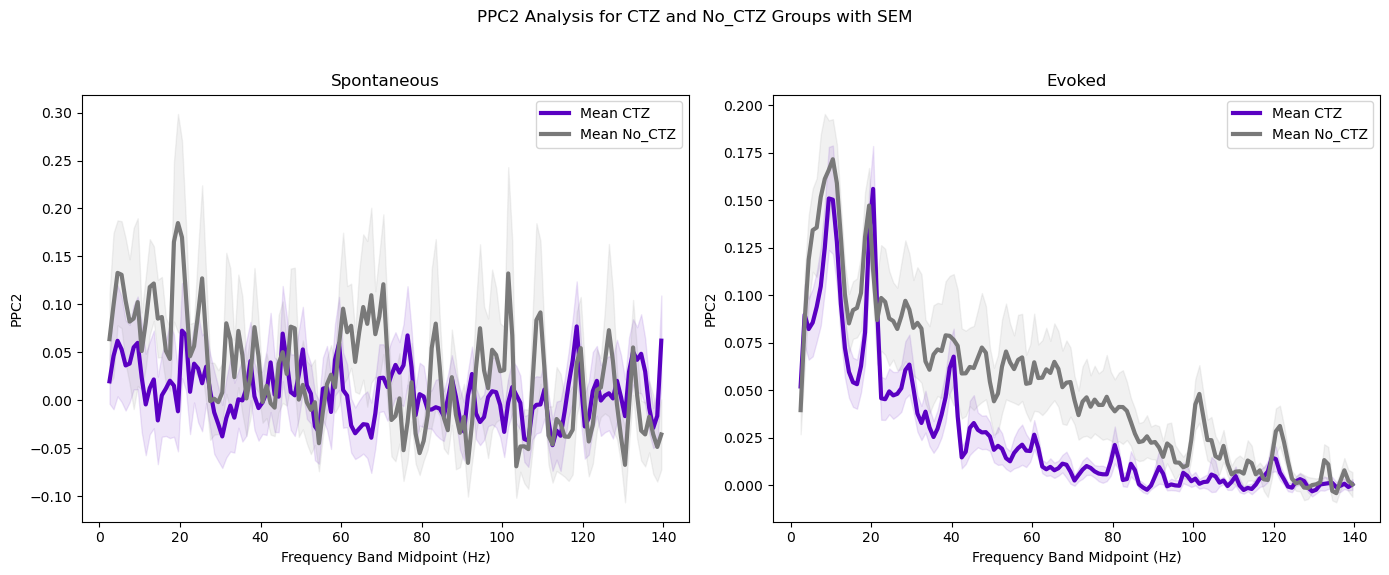

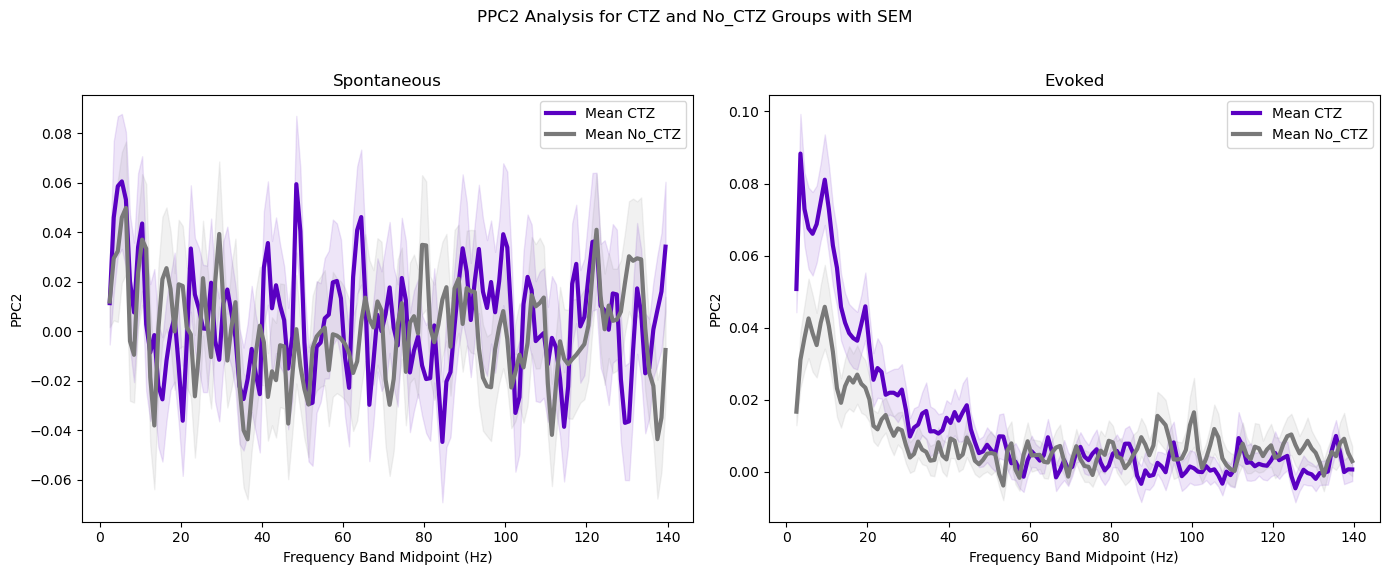

In [130]:
PhaseDataObj.plot_ctz_noctz_ppc2(cell_type='FS', cell_type2=0, show_individual_points=False, smoothing_window=2, min_spikes_evoked=0, min_spikes_spontaneous=0)
PhaseDataObj.plot_ctz_noctz_ppc2(cell_type='RS', cell_type2=0, show_individual_points=False, smoothing_window=2, min_spikes_evoked=0, min_spikes_spontaneous=0)

In [ ]:
#intialize the ccg handler
#CrossCorrObj = CCGHandler(whisker, '/Volumes/MannySSD/Data/ccgs')
CrossCorrObj = CCGHandler(whisker, '/Volumes/MannySSD/new_ccgs_manny')

In [ ]:
CrossCorrObj.is_significant_ccg()
CrossCorrObj.ccg['MonoConnectionsTable']

#fpr the no CTZ group find the top most ExcessSynchrony 



In [ ]:
# Step 1: Sort the DataFrame by 'ExcessSynchrony' in descending order
df_sorted = CrossCorrObj.ccg['MonoConnectionsTable'].sort_values(by='ExcessSynchrony', ascending=False)

# Step 2: View the top 5 cells
top_5_cells = df_sorted.head(30)
top_5_cells

In [ ]:
x = CrossCorrObj.access_ccgs('CTZ', significance=None, EorI=['S'], connectiontype='FS->FS', response=None, layers=None, min_spike_pairs=2000) 
x

In [ ]:
CrossCorrObj.access_ccgs('No_CTZ', significance=None, EorI=['S'], connectiontype='FS->FS', response=None, layers=None, min_spike_pairs=2000) 

In [ ]:
CrossCorrObj.ccg['MonoConnectionsTable'].groupby(['groupname', 'Significance']).size()


In [ ]:
CrossCorrObj.ccg['MonoConnectionsTable'].groupby(['groupname', 'sd_sig']).size()

In [ ]:
#group by groupname and EorI and count the number of connections
CrossCorrObj.ccg['MonoConnectionsTable'].groupby(['groupname', 'EorI']).size()

In [ ]:
CrossCorrObj.plot_group_ccgs_traces(significance=None, sd_sig=None, EorI=['S'], connectiontype='FS->FS', response=None, layers=None, min_spike_pairs=2000, xlim=(-30,30), front_group='No_CTZ')
CrossCorrObj.plot_group_ccgs_traces(significance=None, sd_sig=None, EorI=['S'], connectiontype='RS->RS', response=None, layers=None, min_spike_pairs=2000, xlim=(-30,30))
CrossCorrObj.plot_group_ccgs_traces(significance=None, sd_sig=True, EorI=None, connectiontype='FS->FS', response=None, layers=None, min_spike_pairs=2000, xlim=(-50,50))
CrossCorrObj.plot_group_ccgs_traces(significance=None, sd_sig=True, EorI=None, connectiontype='RS->RS', response=None, layers=None, min_spike_pairs=2000, xlim=(-50,50))

In [ ]:
CrossCorrObj.plot_group_ccgs(significance=None, sd_sig=None, EorI=['S'], connectiontype='FS->FS', response=None, layers=None, min_spike_pairs=150, xlim=(-100,100), front_group='No_CTZ')
CrossCorrObj.plot_group_ccgs(significance=None, sd_sig=None, EorI=['S'], connectiontype='RS->RS', response=None, layers=None, min_spike_pairs=5000, xlim=(-100,100))
CrossCorrObj.plot_group_ccgs(significance=None, sd_sig=True, EorI=['S'], connectiontype='FS->FS', response=None, layers=None, min_spike_pairs=5000, xlim=(-100,100), front_group='No_CTZ')
CrossCorrObj.plot_group_ccgs(significance=None, sd_sig=True, EorI=['S'], connectiontype='RS->RS', response=None, layers=None, min_spike_pairs=5000,xlim=(-100,100))
CrossCorrObj.plot_group_ccgs(significance=None, sd_sig=True, EorI=None, connectiontype='FS->FS', response=None, layers=None, min_spike_pairs=5000, xlim=(-100,100), front_group='No_CTZ')
CrossCorrObj.plot_group_ccgs(significance=None, sd_sig=True, EorI=None, connectiontype='RS->RS', response=None, layers=None, min_spike_pairs=5000, xlim=(-100,100), front_group='CTZ')

In [ ]:
CrossCorrObj.plot_group_ccgs(significance=None, sd_sig=None, EorI=['S'], connectiontype='FS->FS', response=None, layers=None, min_spike_pairs=1000, xlim=(-30,30), front_group='No_CTZ')
CrossCorrObj.plot_group_ccgs(significance=None, sd_sig=None, EorI=['S'], connectiontype='RS->RS', response=None, layers=None, min_spike_pairs=1000, xlim=(-30,30))

CrossCorrObj.plot_group_ccgs(significance=None, EorI=None, connectiontype='FS->FS', response=None, layers=None, min_spike_pairs=1000, xlim=(-30,30), front_group='No_CTZ')
CrossCorrObj.plot_group_ccgs(significance=None, EorI=None, connectiontype='RS->RS', response=None, layers=None, min_spike_pairs=1000, xlim=(-30,30))

CrossCorrObj.plot_group_ccgs(significance=None, EorI=['E'], connectiontype='FS->FS', response=None, layers=None, min_spike_pairs=1000, xlim=(-30,30), front_group='No_CTZ')
CrossCorrObj.plot_group_ccgs(significance=None, EorI=['I'], connectiontype='RS->RS', response=None, layers=None, min_spike_pairs=1000, xlim=(-30,30))

CrossCorrObj.plot_group_ccgs(significance=None, EorI=['I'], connectiontype='FS->FS', response=None, layers=None, min_spike_pairs=1000, xlim=(-30,30), front_group='No_CTZ')
CrossCorrObj.plot_group_ccgs(significance=None, EorI=['E'], connectiontype='RS->RS', response=None, layers=None, min_spike_pairs=1000, xlim=(-30,30))




In [ ]:
CrossCorrObj.plot_group_ccgs(significance=True, EorI=['E', 'I', 'S'], connectiontype='FS->FS', xlim=(-50,50)) #plots the overlaid mean CCGs for the 'No_CTZ' and 'CTZ' groups with their SEM as shaded regions
CrossCorrObj.plot_group_ccgs(significance=True, EorI=['E', 'I', 'S'], connectiontype='RS->RS', xlim=(-50,50)) #plots the overlaid mean CCGs for the 'No_CTZ' and 'CTZ' groups with their SEM as shaded regions

In [ ]:
CrossCorrObj.plot_group_ccgs(significance=True, EorI=['E'], connectiontype='FS->FS', xlim=(None), response='nonreponsive', layers=None, min_spike_pairs=100) #plots the overlaid mean CCGs for the 'No_CTZ' and 'CTZ' groups with their SEM as shaded regions
CrossCorrObj.plot_group_ccgs(significance=True, EorI=['E'], connectiontype='RS->RS', xlim=(None), response='nonresponsive', layers=None, min_spike_pairs=100) #plots the overlaid mean CCGs for the 'No_CTZ' and 'CTZ' groups with their SEM as shaded regions

In [ ]:
CrossCorrObj.plot_group_ccgs(significance=True, EorI=['I'], connectiontype='FS->FS', xlim=(-10,10)) #plots the overlaid mean CCGs for the 'No_CTZ' and 'CTZ' groups with their SEM as shaded regions
CrossCorrObj.plot_group_ccgs(significance=True, EorI=['I'], connectiontype='RS->RS', xlim=(-10,10)) #plots the overlaid mean CCGs for the 'No_CTZ' and 'CTZ' groups with their SEM as shaded regions

In [ ]:
CrossCorrObj.plot_box_and_strip_ccg(groups=['No_CTZ', 'CTZ'], cell_types=['FS->FS', 'RS->RS'], show_outliers=True, hue_order=None) #plots boxplots and stripplots for specified groups and cell types, with color adjustments made directly in the plotting calls

In [ ]:
CrossCorrObj.access_ccgs('No_CTZ', significance=False, EorI=['NS', 'E'], connectiontype='FS->FS') #accesses CCGs from 'MonoConnectionsTable' based on specified criteria

In [ ]:
CrossCorrObj.eed.group_names # the names of the groups in the eed object
CrossCorrObj.eed.recording_names # the names of the recordings in the eed object for the group

In [ ]:
whisker_df_manager = DataFrameManager(whisker)
whisker_df_manager.eed
whisker_df_manager.create_dataframe(['Cell_Type', 'IsSingleUnit', 'StimResponsivity', 'MeanFR_baseline', 'MeanFR_stim','LaminarLabel', 'PeakEvokedFR', 'PeakEvokedFR_Latency', 'FanoFactor_baseline', 'FanoFactor_stim', 'SpikeTimes_all', 'MeanFR_inst_stim' ], 'basic_metrics')
whisker_df_manager.create_psth_dataframe()
whisker_df_manager.calculate_basic_stats('CTZ', 'No_CTZ', stim_label=None, baseline_range=(-100, -1), stim_range=(15, 20), cell_type='FS', is_single_unit=1.0, stim_responsivity=1.0, smoothing_window=None)
whisker_df_manager.prepare_for_boxplot()
whisker_df_manager.plot_box_and_strip(groups=['CTZ', 'No_CTZ'], stimulations=None, show_outliers=True)

In [ ]:
whisker_df_manager.eed
whisker_df_manager.create_dataframe(['Cell_Type', 'IsSingleUnit', 'StimResponsivity', 'SpikeTimes_all', 'FirstSpikeLatency', 'FirstSpikeLatency_Reliability', 'ISI_baseline_CV', 'ISI_baseline_vec', 'ISI_pdf_peak_xy', 'ISI_pdf_x', 'ISI_pdf_y'  ], 'temporal_spiking_metrics')


In [ ]:
whisker_df_manager.dataframes['temporal_spiking_metrics'].groupby(['groupname', 'Cell_Type']).size()

In [ ]:
whisker_df_manager.unpack_based_on_stim('temporal_spiking_metrics', 'FirstSpikeLatency', cell_type_filter='FS', is_single_unit=True, stim_responsivity_filter=None)


In [ ]:
whisker_df_manager.plot_box_and_strip_default(groups=['CTZ', 'No_CTZ'], stimulations=['Low', 'Mid', 'Max'], show_outliers=False, dataframe_key='temporal_spiking_metrics', list_column='FirstSpikeLatency', cell_type_filter='RS', is_single_unit=True, stim_responsivity_filter=1, remove_outliers_option=True)
whisker_df_manager.plot_box_and_strip_default(groups=['CTZ', 'No_CTZ'], stimulations=['Low', 'Mid', 'Max'], show_outliers=False, dataframe_key='temporal_spiking_metrics', list_column='FirstSpikeLatency_Reliability', cell_type_filter='RS', is_single_unit=True, stim_responsivity_filter=1, remove_outliers_option=True)
whisker_df_manager.plot_box_and_strip_default(groups=['CTZ', 'No_CTZ'], stimulations=['Low', 'Mid', 'Max'], show_outliers=False, dataframe_key='temporal_spiking_metrics', list_column='FirstSpikeLatency', cell_type_filter='FS', is_single_unit=True, stim_responsivity_filter=1, remove_outliers_option=True)
whisker_df_manager.plot_box_and_strip_default(groups=['CTZ', 'No_CTZ'], stimulations=['Low', 'Mid', 'Max'], show_outliers=False, dataframe_key='temporal_spiking_metrics', list_column='FirstSpikeLatency_Reliability', cell_type_filter='FS', is_single_unit=True, stim_responsivity_filter=1, remove_outliers_option=True)



In [ ]:
whisker_df_manager.plot_rasters_for_cid('CTZ', 'ctz_2303_1', 'cid296', time_window=None)
whisker_df_manager.plot_combined_psth_and_raster('CTZ', 'ctz_2303_1', 'cid296', time_window=None)
whisker_df_manager.plot_combined_psth_and_raster_normalized('CTZ', 'ctz_2303_1', 'cid296', time_window=None, smoothing_window=5, normalize=False)
whisker_df_manager.plot_all_stimulations_with_stim('CTZ', 'No_CTZ', cell_type='RS', is_single_unit=1.0, stim_responsivity=None, time_range=(-10,200), plot_mode='sem', smoothing_window=8)
whisker_df_manager.plot_psth_comparison('CTZ', 'No_CTZ', stim_label='Low', cell_type='RS', is_single_unit=1.0, stim_responsivity=1.0, time_range=(-10, 50),  plot_mode='sem', smoothing_window=None)
whisker_df_manager.plot_all_stimulations('CTZ', 'No_CTZ', cell_type='RS', is_single_unit=1.0, stim_responsivity=1.0, time_range=(-10, 50), plot_mode='sem', smoothing_window=5)
whisker_df_manager.plot_all_stimulations('CTZ', 'No_CTZ', cell_type='FS', is_single_unit=1.0, stim_responsivity=1.0, time_range=(-10, 50), plot_mode='sem', smoothing_window=5)
whisker_df_manager.plot_all_stimulations('CTZ', 'No_CTZ', cell_type='RS', is_single_unit=1.0, stim_responsivity=None, time_range=(-10, 50), plot_mode='sem', smoothing_window=5)
whisker_df_manager.plot_all_stimulations('CTZ', 'No_CTZ', cell_type='FS', is_single_unit=1.0, stim_responsivity=None, time_range=(-10, 50), plot_mode='sem', smoothing_window=5)

In [ ]:
whisker_df_manager.plot_all_stimulations_with_stim('CTZ', 'No_CTZ', cell_type='FS', is_single_unit=1.0, stim_responsivity=1.0, time_range=(0,200), plot_mode='sem', smoothing_window=8)
whisker_df_manager.plot_all_stimulations_with_stim('CTZ', 'No_CTZ', cell_type='FS', is_single_unit=1.0, stim_responsivity=None, time_range=(0,200), plot_mode='sem', smoothing_window=8)


In [ ]:
whisker_df_manager.plot_all_stimulations('CTZ', 'No_CTZ', cell_type='RS', is_single_unit=1.0, stim_responsivity=1.0, time_range=None, plot_mode='sem', smoothing_window=8)
whisker_df_manager.plot_all_stimulations('CTZ', 'No_CTZ', cell_type='RS', is_single_unit=1.0, stim_responsivity=0.0, time_range=None, plot_mode='sem', smoothing_window=8)

In [ ]:
whisker_df_manager.get_filtered_data('basic_metrics', is_single_unit=None, cell_type=None, stim_responsivity=None).head()

In [ ]:
whisker_df_manager.plot_rasters_for_cid('CTZ', 'ctz_2303_1', 'cid296', time_window=None)
whisker_df_manager.plot_combined_psth_and_raster('CTZ', 'ctz_2303_1', 'cid296', time_window=None, show=False)
whisker_df_manager.plot_combined_psth_and_raster_normalized('CTZ', 'ctz_2303_1', 'cid296', time_window=None, normalize=True, show=False)

In [ ]:
psth = whisker_df_manager.calculate_psth_data('CTZ', 'ctz_2303_1', 'cid296', time_window=None, normalize=True, filter_empty_trials=False)
#plot the psths for four stimulations in the same a 1x4 subplot of the psth
fig, ax = plt.subplots(1, 4, figsize=(20, 5), sharey=True)
for i, (stim, data) in enumerate(psth.items()):
    ax[i].plot(data['time_array'], data['counts'], label=stim)
    ax[i].set_title(stim)
    ax[i].set_xlabel('Time (ms)')
    ax[i].set_ylabel('Spike Rate')

In [ ]:
mean_df, detailed_df, _ = whisker_df_manager.calculate_all_psths(is_single_unit=None, cell_type='FS', stim_responsivity=None, time_window=(0,50), normalize=True, filter_empty_trials=True)
stats_df, _= whisker_df_manager.plot_mean_stimulation_box_and_strip2(mean_df, groups=['CTZ', 'No_CTZ'], remove_outliers_option=True, laminar_labels=['IG'])
stats_df


In [ ]:
stats_df

In [ ]:

#### do not delete this cell neeed to work on the code below fopr custom box plot
def run_group_comparisons(df, group_column='Group', value_column='mean_stimulation', stim_column='Stimulation'):
    """
    Performs statistical comparisons between groups for each type of stimulation, checks for normality,
    uses the appropriate non-parametric tests, and includes detailed descriptive statistics.
    """
    results = []

    for stim in df[stim_column].unique():
        sub_df = df[df[stim_column] == stim]
        groups = sub_df[group_column].unique()

        if len(groups) < 2:
            continue  # Skip if not enough groups for comparison

        group_data = [sub_df[sub_df[group_column] == g][value_column].dropna() for g in groups]
        normality_results = [shapiro(data) for data in group_data]
        normality_p_values = [result.pvalue for result in normality_results]

        # Choose the appropriate statistical test based on group count
        if len(groups) == 2:
            stat, p_value = mannwhitneyu(*group_data)
            test_used = 'Mann-Whitney U'
        elif len(groups) > 2:
            stat, p_value = kruskal(*group_data)
            test_used = 'Kruskal-Wallis'
            # Note: If using Kruskal-Wallis, consider post-hoc tests for detailed group comparisons
        else:
            continue

        descriptive_stats = [{
            'mean': data.mean(),
            'SD': data.std(),
            'median': data.median(),
            'range_min': data.min(),
            'range_max': data.max(),
        } for data in group_data]

        result_entry = {
            'Stimulation': stim,
            'Test Used': test_used,
            'Test Statistic': stat,
            'p-value': p_value,
            **{f'N Group{i+1}': len(data) for i, data in enumerate(group_data)},
            **{f'Normality p-value Group{i+1}': p for i, p in enumerate(normality_p_values)},
            **{f'{stat_key} Group{i+1}': stat_val for i, stats in enumerate(descriptive_stats) for stat_key, stat_val in stats.items()}
        }

        results.append(result_entry)

    return pd.DataFrame(results)



# Example usage in your data processing workflow
cleaned_df = whisker_df_manager.remove_outliers_by_stimulation(mean_df)  # Assuming outliers have been removed
stats_results = run_group_comparisons(cleaned_df)

stats_results

In [ ]:


#make the legend match the colors of the boxplot
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

# Create sample data for two groups and two types of stimulation
data = {
    'Stimulation': np.repeat(['Low', 'Medium', 'High'], 100),  # Three stimulation levels
    'Group': np.tile(np.repeat(['CTZ', 'No_CTZ'], 50), 3),  # Two groups
    'mean_stimulation': np.random.rand(300) + np.repeat([0.5, 1.0, 1.5], 100)  # Staggered base values
}

df = pd.DataFrame(data)

# Create the boxplot
plt.figure(figsize=(12, 6))
ax = sns.boxplot(data=df, x='Stimulation', y='mean_stimulation', hue='Group',
                 medianprops={'linewidth': 5},
                 whiskerprops={'linewidth': 5},
                 capprops={'linewidth': 0},
                 #boxplot properties
                 boxprops={'edgecolor': 'k', 'linewidth': 10},
                 showfliers=False,  # Outliers not shown
                 width=0.55)


# Apply color to whiskers and median to the CTZ group at low stimulation
# Set color for lower whisker (Line 0)
ax.lines[0].set_color('#5a00c2')
# Set color for upper whisker (Line 1)
ax.lines[1].set_color('#5a00c2')
# Set color for the horizontal cap of the lower whisker (Line 2)
ax.lines[2].set_color('#5a00c2')
# Set color for the horizontal cap of the upper whisker (Line 3)
ax.lines[3].set_color('#5a00c2')
# Set color for the median line (Line 4)
ax.lines[4].set_color('#5a00c2')

# Apply color to whiskers and median to the No_CTZ group at low stimulation
# Set color for lower whisker (Line 5)
ax.lines[5].set_color('#797979')
# Set color for upper whisker (Line 6)
ax.lines[6].set_color('#797979')
# Set color for the horizontal cap of the lower whisker (Line 7)
ax.lines[7].set_color('#797979')
# Set color for the horizontal cap of the upper whisker (Line 8)
ax.lines[8].set_color('#797979')
# Set color for the median line (Line 9)
ax.lines[9].set_color('#797979')

#apply color to the CTZ group at medium stimulation
# Set color for lower whisker (Line 10)
ax.lines[10].set_color('#5a00c2')
# Set color for upper whisker (Line 11)
ax.lines[11].set_color('#5a00c2')
# Set color for the horizontal cap of the lower whisker (Line 12)
ax.lines[12].set_color('#5a00c2')
# Set color for the horizontal cap of the upper whisker (Line 13)
ax.lines[13].set_color('#5a00c2')
# Set color for the median line (Line 14)
ax.lines[14].set_color('#5a00c2')

#apply color to the No_CTZ group at medium stimulation
# Set color for lower whisker (Line 15)
ax.lines[15].set_color('#797979')
# Set color for upper whisker (Line 16)
ax.lines[16].set_color('#797979')
# Set color for the horizontal cap of the lower whisker (Line 17)
ax.lines[17].set_color('#797979')
# Set color for the horizontal cap of the upper whisker (Line 18)
ax.lines[18].set_color('#797979')
# Set color for the median line (Line 19)
ax.lines[19].set_color('#797979')

#apply color to the CTZ group at high stimulation
# Set color for lower whisker (Line 20)
ax.lines[20].set_color('#5a00c2')
# Set color for upper whisker (Line 21)
ax.lines[21].set_color('#5a00c2')
# Set color for the horizontal cap of the lower whisker (Line 22)
ax.lines[22].set_color('#5a00c2')
# Set color for the horizontal cap of the upper whisker (Line 23)
ax.lines[23].set_color('#5a00c2')
# Set color for the median line (Line 24)
ax.lines[24].set_color('#5a00c2')

#apply color to the No_CTZ group at high stimulation
# Set color for lower whisker (Line 25)
ax.lines[25].set_color('#797979')
# Set color for upper whisker (Line 26)
ax.lines[26].set_color('#797979')
# Set color for the horizontal cap of the lower whisker (Line 27)
ax.lines[27].set_color('#797979')
# Set color for the horizontal cap of the upper whisker (Line 28)
ax.lines[28].set_color('#797979')
# Set color for the median line (Line 29)
ax.lines[29].set_color('#797979')


#change thte color of the box face of the CTZ group at low stimulation
ax.patches[1].set_facecolor('#5a00c2')
#change thte color of the box face of the No_CTZ group at low stimulation   
ax.patches[3].set_facecolor('#797979')
#change thte color of the box face of the CTZ group at medium stimulation
ax.patches[4].set_facecolor('#5a00c2')
#change thte color of the box face of the No_CTZ group at medium stimulation
ax.patches[5].set_facecolor('#797979')
#change thte color of the box face of the CTZ group at high stimulation
ax.patches[6].set_facecolor('#5a00c2')
#change thte color of the box face of the No_CTZ group at high stimulation
ax.patches[7].set_facecolor('#797979')



legend_elements = [Line2D([0], [0], color='#5a00c2', lw=10, label='CTZ'),
                     Line2D([0], [0], color='#797979', lw=10, label='No_CTZ')]

ax.legend(handles=legend_elements, title='Group')

# Display the plot
plt.title('Boxplot for Two Groups and Three Stimulations')
plt.show()

In [ ]:
whisker_df_manager.plot_group_cell_distribution()

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# Function to pad arrays to the maximum length found in any array
def pad_array_to_max_length(arr, max_length):
    padding = max_length - len(arr)
    if padding > 0:
        return np.pad(arr, (0, padding), 'constant', constant_values=(0,))
    return arr

# Function to plot the heatmaps with time bins on the x-axis and adjustable colormap range
def plot_group_stimulation_heatmaps(df, vmin=None, vmax=None):
    groupnames = df['groupname'].unique()
    stimulations = ['Zero', 'Low', 'Mid', 'Max']
    num_groups = len(groupnames)
    
    # Create a subplot grid with 2 rows (or more if more groups) and 4 columns
    fig, axes = plt.subplots(num_groups, 4, figsize=(20, 5 * num_groups), sharex='col', sharey='row')
    
    # If no specific vmin and vmax are provided, determine them from the data
    if vmin is None or vmax is None:
        vmin = df['counts'].apply(np.min).min()  # Minimum value across all counts
        vmax = df['counts'].apply(np.max).max()  # Maximum value

    # Iterate over each group and stimulation to create each subplot
    for i, group in enumerate(groupnames):
        for j, stim in enumerate(stimulations):
            ax = axes[i, j] if num_groups > 1 else axes[j]
            
            # Filter DataFrame for the current group and stimulation
            stim_df = df[(df['groupname'] == group) & (df['Stimulation'] == stim)]

            if not stim_df.empty:
                # Find the maximum length of arrays in the 'counts' column for current group and stimulation
                max_length = stim_df['counts'].map(len).max()

                # Pad all 'counts' arrays to this maximum length
                padded_counts = stim_df['counts'].apply(lambda x: pad_array_to_max_length(x, max_length))

                # Stack the padded counts to create a matrix
                counts_matrix = np.stack(padded_counts.values)
                
                # Extract the time_array from the first row of the filtered DataFrame
                time_bins = stim_df.iloc[0]['time_array']
                num_ticks = min(len(time_bins), 10)
                tick_positions = np.linspace(0, len(time_bins) - 1, num_ticks, dtype=int)
                tick_labels = [f"{time_bins[pos]:.0f}" for pos in tick_positions]

                # Plot the heatmap with user-defined or data-driven color range
                sns.heatmap(counts_matrix, ax=ax, cmap="viridis", vmin=vmin, vmax=vmax, cbar=(j == len(stimulations) - 1))
                
                # Set x-ticks to align with time bins
                ax.set_xticks(tick_positions)
                ax.set_xticklabels(tick_labels, rotation=45, ha='right')
                
                ax.set_title(f'{group} - {stim}')
                ax.set_xlabel('Time (ms)')
                if j == 0:
                    ax.set_ylabel('Cells')

    plt.tight_layout()
    plt.show()




In [ ]:
unfiltered_mean_df, unfiltered_detailed_df = whisker_df_manager.calculate_all_psths(is_single_unit=None, cell_type=None, stim_responsivity=None, time_window=(0, 100), normalize=True, filter_empty_trials=True)


In [ ]:
whisker_df_manager.dataframes['psth_dataframe_Zero']

In [ ]:
_, detailed_df_entirepsth= whisker_df_manager.calculate_all_psths(is_single_unit=1.0, cell_type='RS', stim_responsivity=1.0, time_window=(0, 100), normalize=False, filter_empty_trials=False)
plot_group_stimulation_heatmaps(detailed_df_entirepsth)


In [ ]:
_, detailed_df_entirepsth= whisker_df_manager.calculate_all_psths(is_single_unit=1.0, cell_type='FS', stim_responsivity=1.0, time_window=(0, 100), normalize=True, filter_empty_trials=True)
plot_group_stimulation_heatmaps(detailed_df_entirepsth)

testing correlations 

In [ ]:
whisker_df_manager.dataframes['psth_dataframe_Zero']

In [ ]:
# Assuming 'dataframe' is your DataFrame
def find_recording_with_most_single_units(data):
    # Filter data for single units
    single_unit_data = data[data['IsSingleUnit'] == 1.0]

    # Group by recording name and count entries
    counts = single_unit_data.groupby('recordingname').size()

    # Find the recording with the maximum count
    max_single_units = counts.idxmax()
    max_count = counts.max()

    return max_single_units, max_count

max_recording, max_count = find_recording_with_most_single_units(whisker_df_manager.dataframes['psth_dataframe_Zero'])
print(f"The recording with the most single units is {max_recording} with {max_count} single units.")

In [ ]:
whisker_df_manager.extract_spike_trains('veh_3141_2')